In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterio -q

In [ ]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


NDVI:
  Shape: (143, 349)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

EVI:
  Shape: (143, 349)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

Rainfall:
  Shape: (2501, 6248)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 0.55, Max: 10.44, Mean: 4.59

LAI:
  Shape: (143, 349)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

Slope:
  Shape: (427, 1045)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 0.00, Max: 60.96, Mean: 22.13

DEM:
  Shape: (427, 1045)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 1830.00, Max: 2529.00, Mean: 2151.93



/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


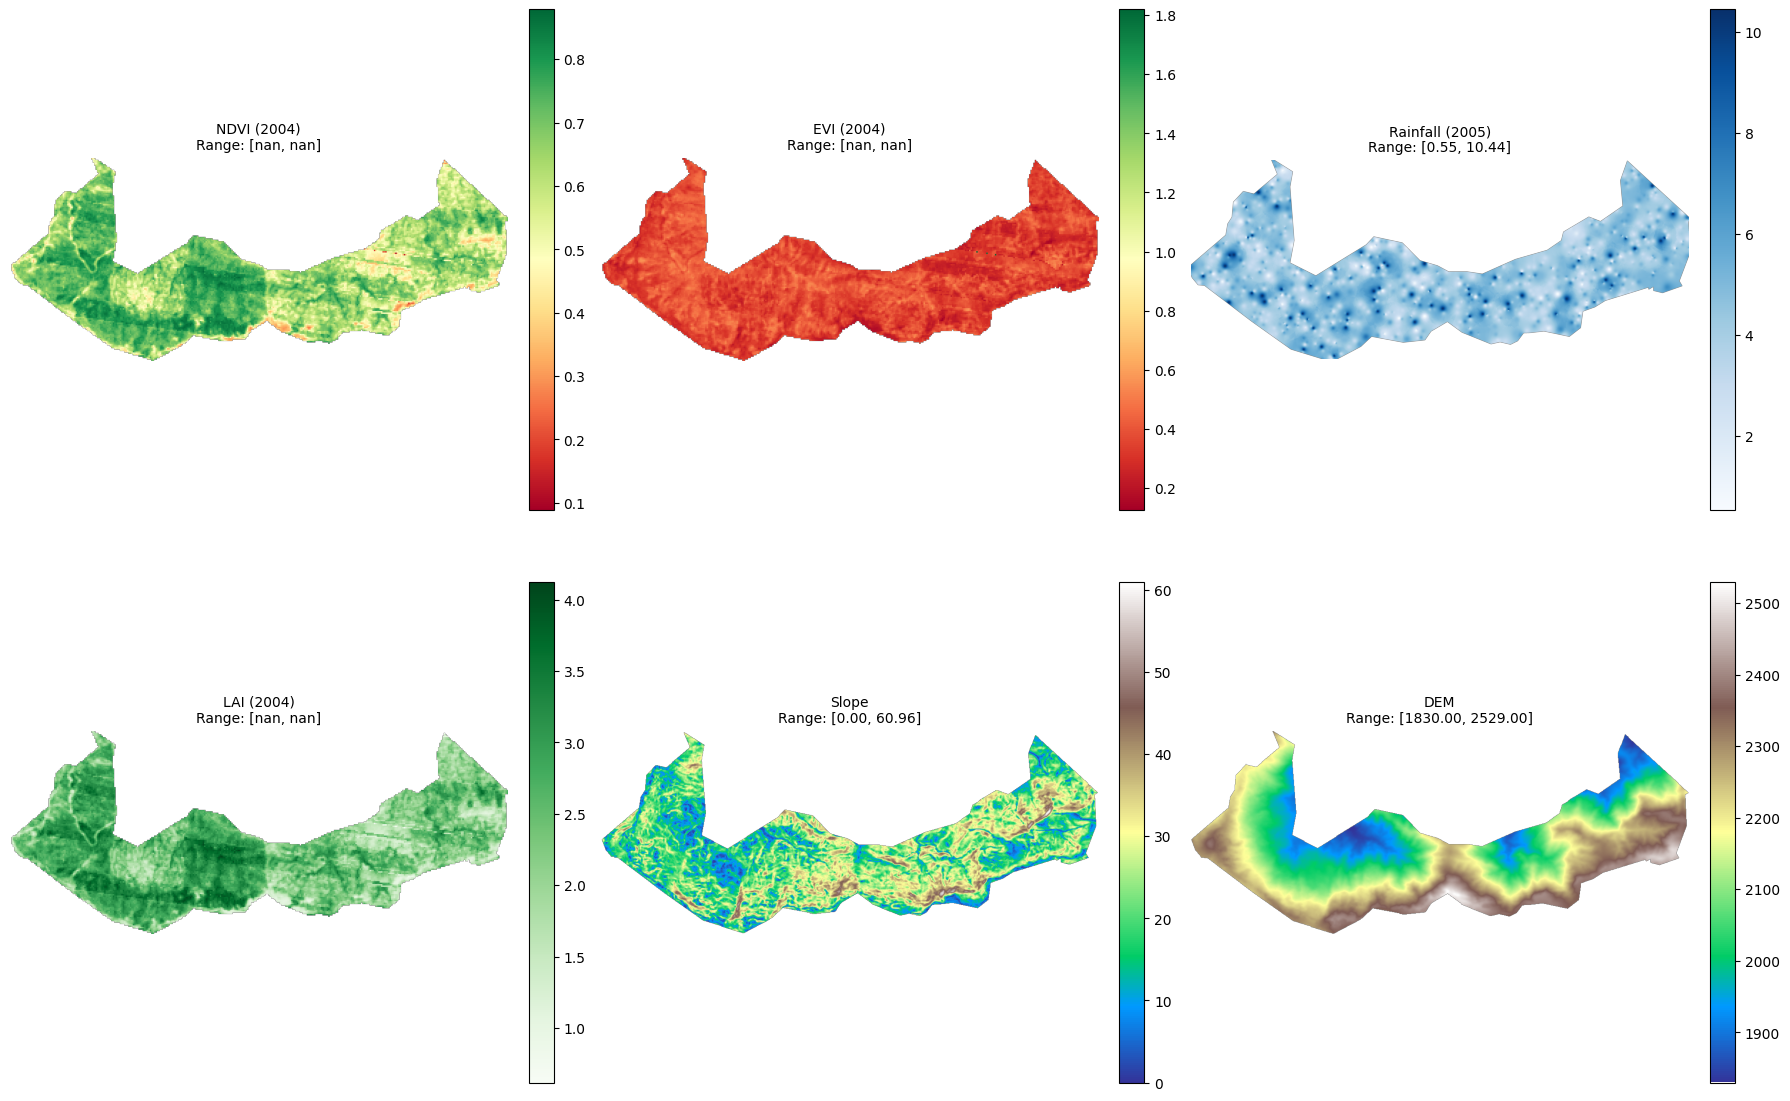


=== Checking spatial alignment ===
NDVI:
  Bounds: BoundingBox(left=35.14586683894898, bottom=1.2528803267614967, right=35.2399204491963, top=1.2914180524502241)
  Resolution: (0.00026949458523585647, 0.00026949458523585647)
  Shape: (143, 349)
EVI:
  Bounds: BoundingBox(left=35.14586683894898, bottom=1.2528803267614967, right=35.2399204491963, top=1.2914180524502241)
  Resolution: (0.00026949458523585647, 0.00026949458523585647)
  Shape: (143, 349)
Rainfall:
  Bounds: BoundingBox(left=35.14667031131769, bottom=1.2536535425728044, right=35.239395262555966, top=1.2907702364023375)
  Resolution: (1.4840741235319206e-05, 1.4840741235319108e-05)
  Shape: (2501, 6248)
LAI:
  Bounds: BoundingBox(left=35.14586683894898, bottom=1.2528803267614967, right=35.2399204491963, top=1.2914180524502241)
  Resolution: (0.00026949458523585647, 0.00026949458523585647)
  Shape: (143, 349)
Slope:
  Bounds: BoundingBox(left=35.14604034767867, bottom=1.2530139836769492, right=35.239992165851795, top=1.291403

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# Define the raster paths for 2004-2005
raster_paths = {
    "NDVI": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2004.tif",
    "EVI": "/content/drive/MyDrive/Kamatira Model Data/EVI_2004_2004.tif",
    "Rainfall": "/content/drive/MyDrive/Kamatira Model Data/Precip_2005.tif",
    "LAI": "/content/drive/MyDrive/Kamatira Model Data/LAI_2004_2004.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define color maps and titles for each raster
cmaps = ['RdYlGn', 'RdYlGn', 'Blues', 'Greens', 'terrain', 'terrain']
titles = ['NDVI (2004)', 'EVI (2004)', 'Rainfall (2005)', 'LAI (2004)', 'Slope', 'DEM']

for idx, (name, path) in enumerate(raster_paths.items()):
    try:
        # Open the raster
        with rasterio.open(path) as src:
            data = src.read(1)
            transform = src.transform
            crs = src.crs

            # Handle nodata values
            if src.nodata is not None:
                data = np.ma.masked_where(data == src.nodata, data)

            # Plot with appropriate scaling
            ax = axes[idx]
            im = ax.imshow(data, cmap=cmaps[idx])

            # Add title with basic stats
            valid_data = data[~data.mask] if isinstance(data, np.ma.MaskedArray) else data
            if len(valid_data) > 0:
                title = f"{titles[idx]}\nRange: [{valid_data.min():.2f}, {valid_data.max():.2f}]"
                ax.set_title(title, fontsize=10)

            ax.set_axis_off()
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # Print basic info
            print(f"{name}:")
            print(f"  Shape: {data.shape}")
            print(f"  CRS: {crs}")
            print(f"  Resolution: {transform[0]:.2f} x {abs(transform[4]):.2f}")
            if len(valid_data) > 0:
                print(f"  Min: {valid_data.min():.2f}, Max: {valid_data.max():.2f}, Mean: {valid_data.mean():.2f}")
            print()

    except Exception as e:
        print(f"Error loading {name}: {e}")
        axes[idx].set_title(f"{titles[idx]} - Failed to load")
        axes[idx].set_axis_off()

plt.tight_layout()
plt.show()

# Also check if they all have the same extent and resolution
print("\n=== Checking spatial alignment ===")
extents = []
resolutions = []
shapes = []

for name, path in raster_paths.items():
    try:
        with rasterio.open(path) as src:
            bounds = src.bounds
            res = (src.transform[0], abs(src.transform[4]))
            shape = src.shape

            extents.append(bounds)
            resolutions.append(res)
            shapes.append(shape)

            print(f"{name}:")
            print(f"  Bounds: {bounds}")
            print(f"  Resolution: {res}")
            print(f"  Shape: {shape}")
    except Exception as e:
        print(f"{name}: Error - {e}")

# Check consistency
if len(set(shapes)) == 1:
    print("\n✓ All rasters have the same shape")
else:
    print(f"\n✗ Rasters have different shapes: {set(shapes)}")

if len(set(resolutions)) == 1:
    print(f"✓ All rasters have the same resolution: {resolutions[0]}")
else:
    print(f"✗ Rasters have different resolutions: {set(resolutions)}")

NDVI_94_95:
  Shape: (851, 2089)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

EVI_94_95:
  Shape: (851, 2089)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

Rain_94_95:
  Shape: (2501, 6248)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 0.55, Max: 10.44, Mean: 4.59

LAI_94_95:
  Shape: (851, 2089)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: nan, Max: nan, Mean: nan

Slope:
  Shape: (427, 1045)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 0.00, Max: 60.96, Mean: 22.13

DEM:
  Shape: (427, 1045)
  CRS: EPSG:4326
  Resolution: 0.00 x 0.00
  Min: 1830.00, Max: 2529.00, Mean: 2151.93



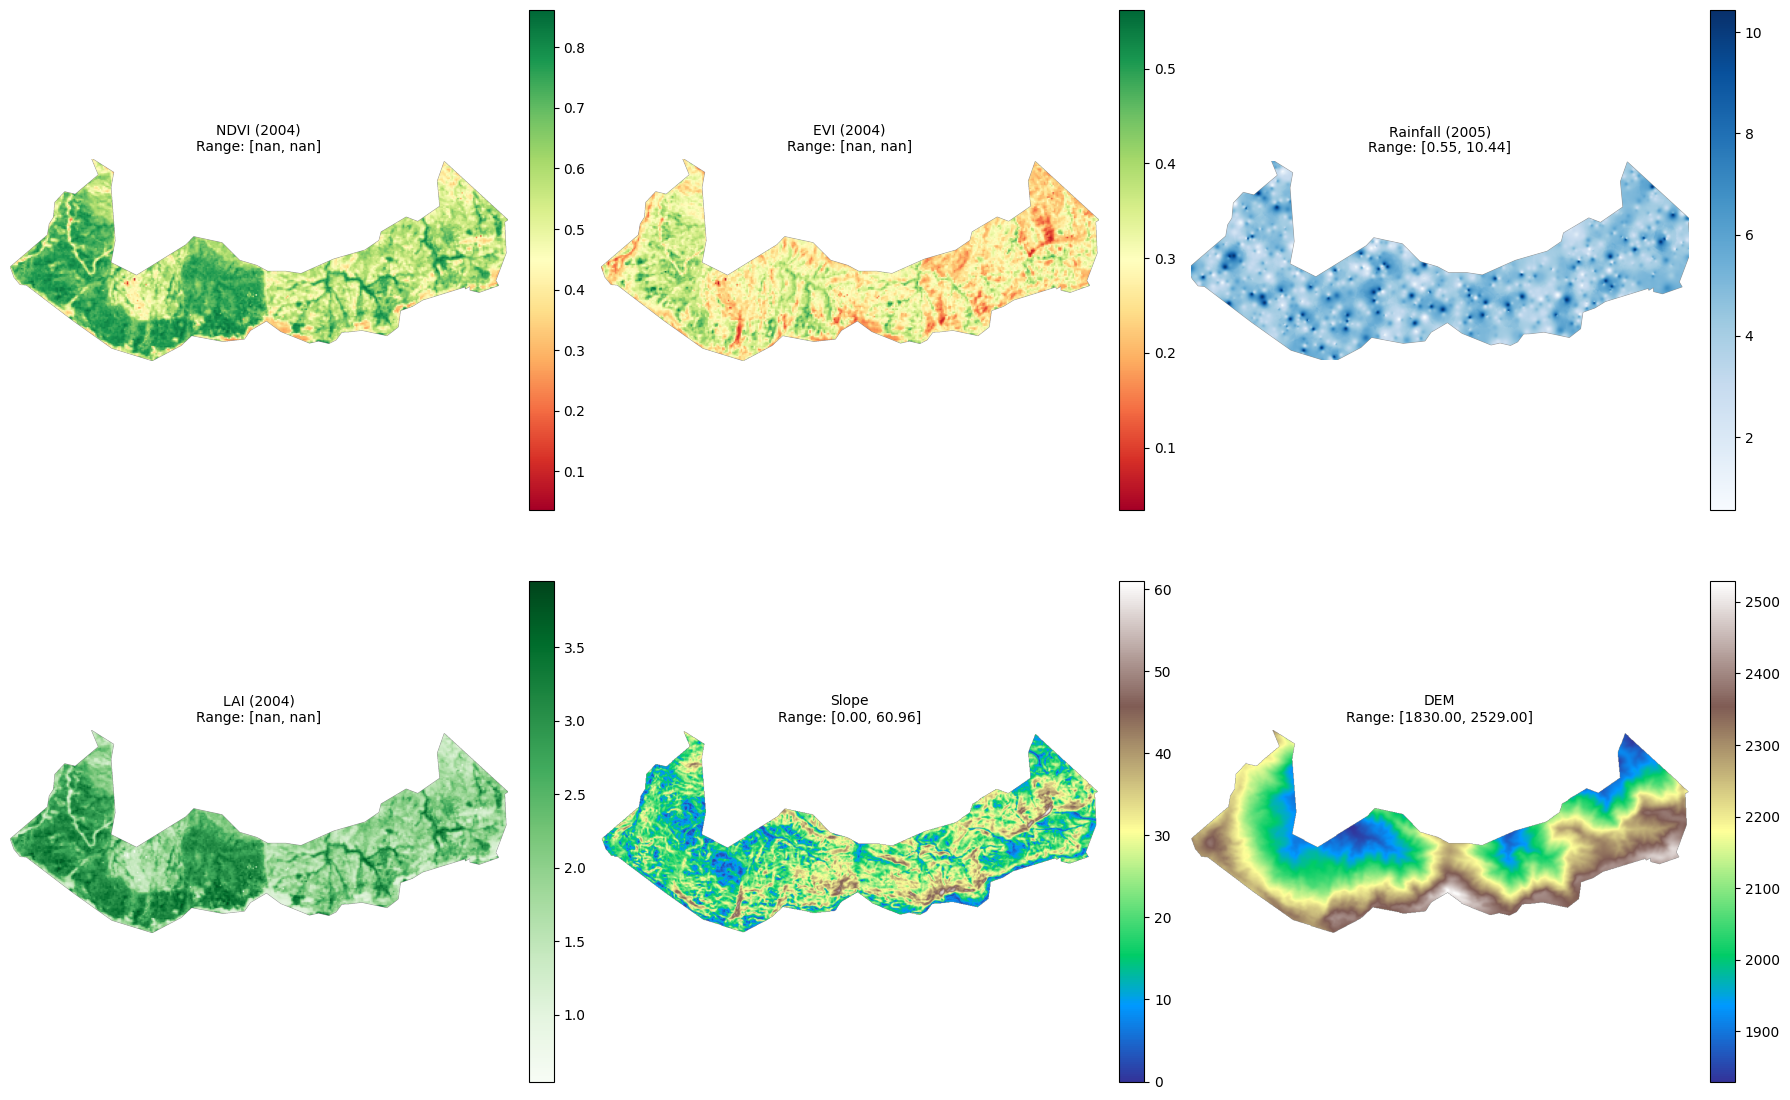


=== Checking spatial alignment ===
NDVI_94_95:
  Bounds: BoundingBox(left=35.14609141777001, bottom=1.2530599898183206, right=35.23992044919629, top=1.2912833051576063)
  Resolution: (4.491576420597607e-05, 4.491576420597607e-05)
  Shape: (851, 2089)
EVI_94_95:
  Bounds: BoundingBox(left=35.14609141777001, bottom=1.2530599898183206, right=35.23992044919629, top=1.2912833051576063)
  Resolution: (4.491576420597607e-05, 4.491576420597607e-05)
  Shape: (851, 2089)
Rain_94_95:
  Bounds: BoundingBox(left=35.14667031131769, bottom=1.2536535425728044, right=35.239395262555966, top=1.2907702364023375)
  Resolution: (1.4840741235319206e-05, 1.4840741235319108e-05)
  Shape: (2501, 6248)
LAI_94_95:
  Bounds: BoundingBox(left=35.14609141777001, bottom=1.2530599898183206, right=35.23992044919629, top=1.2912833051576063)
  Resolution: (4.491576420597607e-05, 4.491576420597607e-05)
  Shape: (851, 2089)
Slope:
  Bounds: BoundingBox(left=35.14604034767867, bottom=1.2530139836769492, right=35.239992165

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# Define the raster paths for 2004-2005
raster_paths = {
            "NDVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1994_1995.tif",
            "EVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/EVI_1994_1995.tif",
            "Rain_94_95": "/content/drive/MyDrive/Kamatira Model Data/Precip_1995.tif",
            "LAI_94_95": "/content/drive/MyDrive/Kamatira Model Data/LAI_1994_1995.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        }

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define color maps and titles for each raster
cmaps = ['RdYlGn', 'RdYlGn', 'Blues', 'Greens', 'terrain', 'terrain']
titles = ['NDVI (2004)', 'EVI (2004)', 'Rainfall (2005)', 'LAI (2004)', 'Slope', 'DEM']

for idx, (name, path) in enumerate(raster_paths.items()):
    try:
        # Open the raster
        with rasterio.open(path) as src:
            data = src.read(1)
            transform = src.transform
            crs = src.crs

            # Handle nodata values
            if src.nodata is not None:
                data = np.ma.masked_where(data == src.nodata, data)

            # Plot with appropriate scaling
            ax = axes[idx]
            im = ax.imshow(data, cmap=cmaps[idx])

            # Add title with basic stats
            valid_data = data[~data.mask] if isinstance(data, np.ma.MaskedArray) else data
            if len(valid_data) > 0:
                title = f"{titles[idx]}\nRange: [{valid_data.min():.2f}, {valid_data.max():.2f}]"
                ax.set_title(title, fontsize=10)

            ax.set_axis_off()
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # Print basic info
            print(f"{name}:")
            print(f"  Shape: {data.shape}")
            print(f"  CRS: {crs}")
            print(f"  Resolution: {transform[0]:.2f} x {abs(transform[4]):.2f}")
            if len(valid_data) > 0:
                print(f"  Min: {valid_data.min():.2f}, Max: {valid_data.max():.2f}, Mean: {valid_data.mean():.2f}")
            print()

    except Exception as e:
        print(f"Error loading {name}: {e}")
        axes[idx].set_title(f"{titles[idx]} - Failed to load")
        axes[idx].set_axis_off()

plt.tight_layout()
plt.show()

# Also check if they all have the same extent and resolution
print("\n=== Checking spatial alignment ===")
extents = []
resolutions = []
shapes = []

for name, path in raster_paths.items():
    try:
        with rasterio.open(path) as src:
            bounds = src.bounds
            res = (src.transform[0], abs(src.transform[4]))
            shape = src.shape

            extents.append(bounds)
            resolutions.append(res)
            shapes.append(shape)

            print(f"{name}:")
            print(f"  Bounds: {bounds}")
            print(f"  Resolution: {res}")
            print(f"  Shape: {shape}")
    except Exception as e:
        print(f"{name}: Error - {e}")

# Check consistency
if len(set(shapes)) == 1:
    print("\n✓ All rasters have the same shape")
else:
    print(f"\n✗ Rasters have different shapes: {set(shapes)}")

if len(set(resolutions)) == 1:
    print(f"✓ All rasters have the same resolution: {resolutions[0]}")
else:
    print(f"✗ Rasters have different resolutions: {set(resolutions)}")


Analyzing: NDVI_04_05
Path: /content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2004.tif
CRS: EPSG:4326
Driver: GTiff
Count (bands): 1
Width x Height: 349 x 143
Bounds: BoundingBox(left=35.14586683894898, bottom=1.2528803267614967, right=35.2399204491963, top=1.2914180524502241)
Resolution: (0.00026949458523585647, 0.00026949458523585647)
Transform:
| 0.00, 0.00, 35.15|
| 0.00,-0.00, 1.29|
| 0.00, 0.00, 1.00|
NoData value: None
NoData value: Not specified
Min: nan
Max: nan
Mean: nan
Std: nan
Median: nan
Potential outliers: 0 (0.00%)

Analyzing: EVI_04_05
Path: /content/drive/MyDrive/Kamatira Model Data/EVI_2004_2004.tif
CRS: EPSG:4326
Driver: GTiff
Count (bands): 1
Width x Height: 349 x 143
Bounds: BoundingBox(left=35.14586683894898, bottom=1.2528803267614967, right=35.2399204491963, top=1.2914180524502241)
Resolution: (0.00026949458523585647, 0.00026949458523585647)
Transform:
| 0.00, 0.00, 35.15|
| 0.00,-0.00, 1.29|
| 0.00, 0.00, 1.00|
NoData value: None
NoData value: Not specified

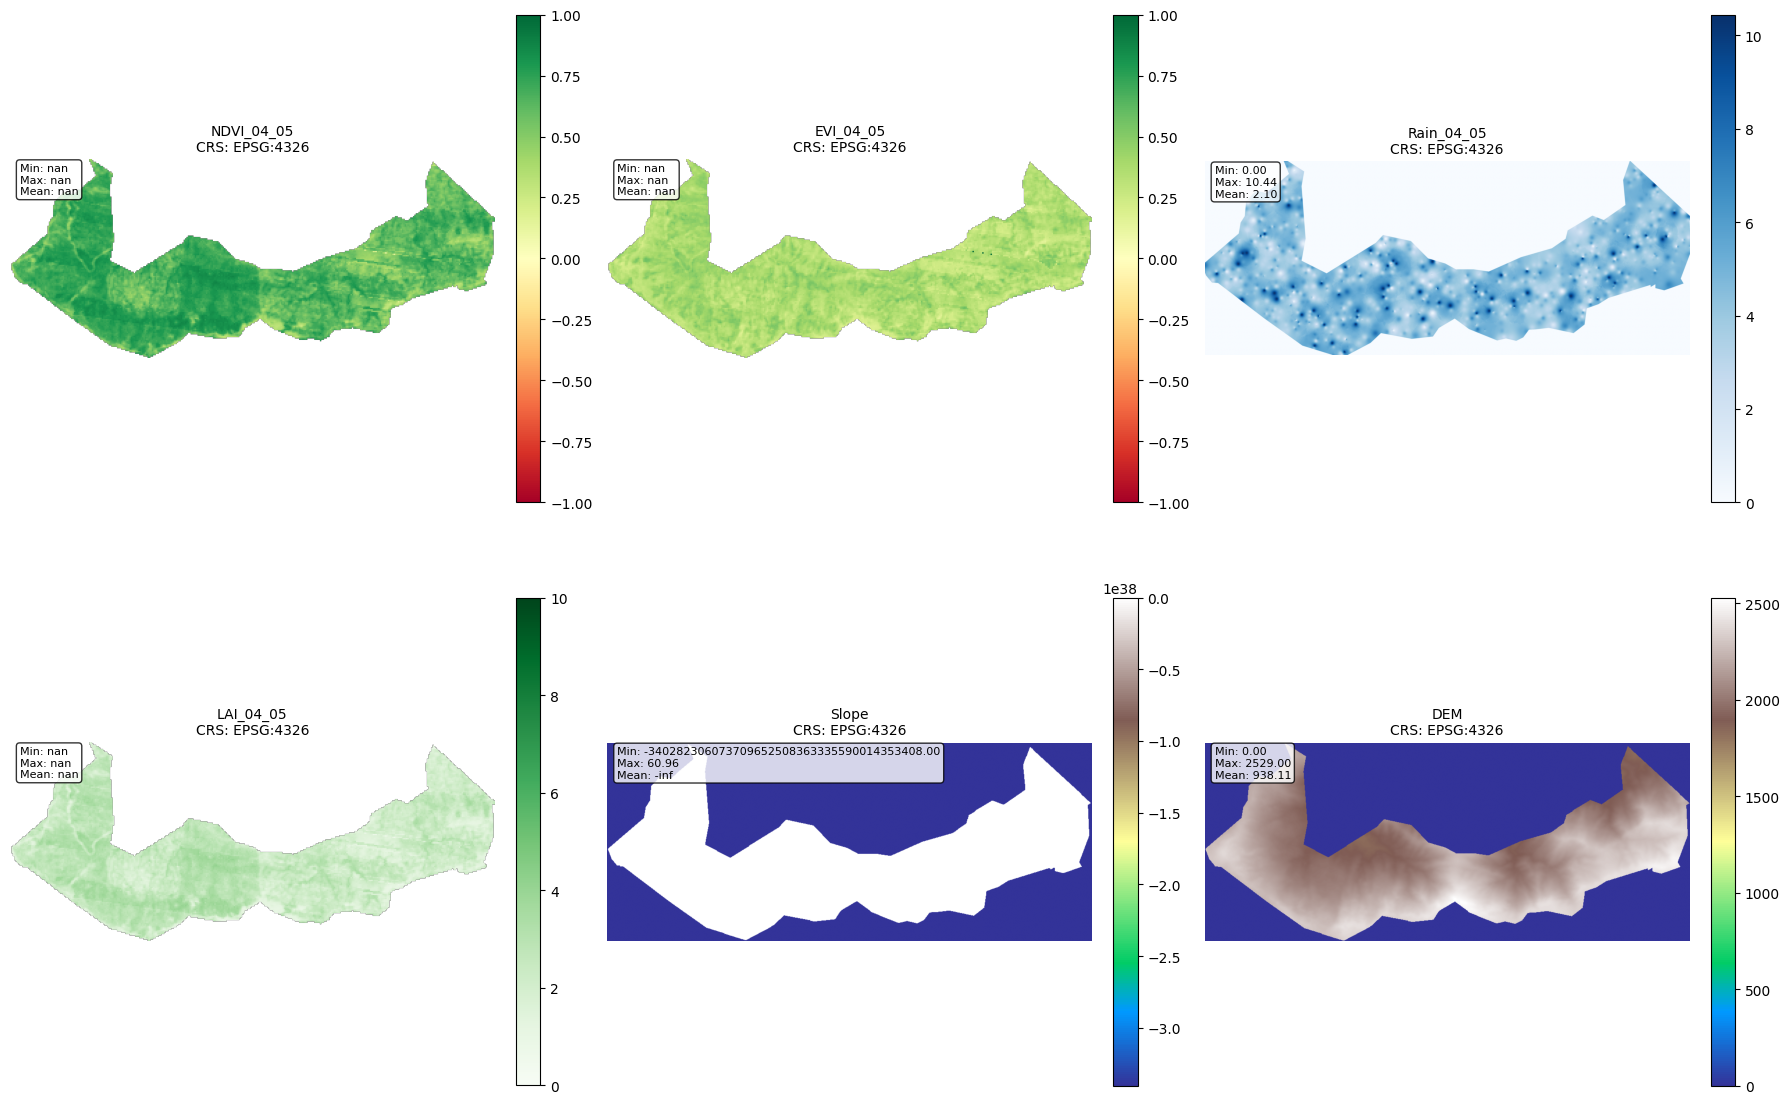


POTENTIAL ISSUES SUMMARY
⚠️  Rain_04_05: High NoData percentage (54.4%)
⚠️  Rain_04_05: Non-square pixels (1.4840741235319206e-05 x 1.4840741235319108e-05)
⚠️  Slope: High NoData percentage (57.0%)
⚠️  DEM: High NoData percentage (56.4%)

These issues could explain your model's poor performance!

RECOMMENDED ACTIONS BASED ON FINDINGS
1. If CRS differ: Reproject all to same CRS
2. If resolutions differ: Resample to common resolution
3. If extents differ: Clip to common extent
4. If high NoData: Consider gap-filling or masking
5. If value ranges unrealistic: Check scaling/calibration


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import warnings
warnings.filterwarnings('ignore')

# Define the raster paths
raster_paths = {
    "NDVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2004.tif",
    "EVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/EVI_2004_2004.tif",
    "Rain_04_05": "/content/drive/MyDrive/Kamatira Model Data/Precip_2005.tif",
    "LAI_04_05": "/content/drive/MyDrive/Kamatira Model Data/LAI_2004_2004.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

# Function to analyze a raster
def analyze_raster(name, path):
    print(f"\n{'='*60}")
    print(f"Analyzing: {name}")
    print(f"Path: {path}")
    print('='*60)

    try:
        with rasterio.open(path) as src:
            # Basic metadata
            print(f"CRS: {src.crs}")
            print(f"Driver: {src.driver}")
            print(f"Count (bands): {src.count}")
            print(f"Width x Height: {src.width} x {src.height}")
            print(f"Bounds: {src.bounds}")
            print(f"Resolution: {src.res}")
            print(f"Transform:\n{src.transform}")
            print(f"NoData value: {src.nodata}")

            # Read the data
            data = src.read(1)

            # Handle NoData
            if src.nodata is not None:
                mask = data == src.nodata
                valid_data = data[~mask]
                nodata_count = np.sum(mask)
                nodata_percent = (nodata_count / data.size) * 100
                print(f"NoData pixels: {nodata_count:,} ({nodata_percent:.2f}%)")
            else:
                valid_data = data.flatten()
                nodata_count = 0
                print("NoData value: Not specified")

            # Statistics
            if len(valid_data) > 0:
                print(f"Min: {valid_data.min():.6f}")
                print(f"Max: {valid_data.max():.6f}")
                print(f"Mean: {valid_data.mean():.6f}")
                print(f"Std: {valid_data.std():.6f}")
                print(f"Median: {np.median(valid_data):.6f}")

                # Check for anomalies
                q1 = np.percentile(valid_data, 25)
                q3 = np.percentile(valid_data, 75)
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr

                outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]
                print(f"Potential outliers: {len(outliers):,} ({len(outliers)/len(valid_data)*100:.2f}%)")

                # Check for extreme values based on expected ranges
                if "NDVI" in name or "EVI" in name:
                    # NDVI/EVI should typically be between -1 and 1
                    extreme = valid_data[(valid_data < -1) | (valid_data > 1)]
                    if len(extreme) > 0:
                        print(f"⚠️  WARNING: {len(extreme):,} pixels outside expected [-1, 1] range")

                if "LAI" in name:
                    # LAI typically 0-10 for most vegetation
                    extreme = valid_data[valid_data > 15]
                    if len(extreme) > 0:
                        print(f"⚠️  WARNING: {len(extreme):,} pixels with LAI > 15 (unusually high)")

                if "Rain" in name:
                    # Check for unrealistic precipitation (e.g., negative values)
                    negative = valid_data[valid_data < 0]
                    if len(negative) > 0:
                        print(f"⚠️  WARNING: {len(negative):,} negative precipitation values")

            else:
                print("⚠️  WARNING: No valid data found!")

            # Check for common anomalies
            unique_vals = np.unique(data)
            if len(unique_vals) < 20:
                print(f"Unique values: {unique_vals}")

            return {
                'name': name,
                'crs': src.crs,
                'bounds': src.bounds,
                'shape': (src.height, src.width),
                'res': src.res,
                'nodata_percent': nodata_percent if 'nodata_percent' in locals() else 0,
                'data': data
            }

    except Exception as e:
        print(f"❌ ERROR: {e}")
        return None

# Analyze all rasters
raster_info = []
for name, path in raster_paths.items():
    info = analyze_raster(name, path)
    if info:
        raster_info.append(info)

# Compare CRS across all rasters
print(f"\n{'='*60}")
print("CRS COMPARISON")
print('='*60)

crs_list = [info['crs'] for info in raster_info if info]
unique_crs = set(crs_list)

if len(unique_crs) == 1:
    print(f"✓ All rasters have the same CRS: {list(unique_crs)[0]}")
else:
    print(f"✗ Multiple CRS found:")
    for crs in unique_crs:
        rasters_with_crs = [info['name'] for info in raster_info if info and info['crs'] == crs]
        print(f"  {crs}: {rasters_with_crs}")

# Compare extents and resolutions
print(f"\n{'='*60}")
print("SPATIAL ALIGNMENT CHECK")
print('='*60)

# Check resolutions
resolutions = [info['res'] for info in raster_info if info]
unique_res = set(resolutions)

if len(unique_res) == 1:
    print(f"✓ All rasters have the same resolution: {list(unique_res)[0]}")
else:
    print(f"✗ Multiple resolutions found:")
    for res in unique_res:
        rasters_with_res = [info['name'] for info in raster_info if info and info['res'] == res]
        print(f"  {res}: {rasters_with_res}")

# Check shapes
shapes = [info['shape'] for info in raster_info if info]
unique_shapes = set(shapes)

if len(unique_shapes) == 1:
    print(f"✓ All rasters have the same shape: {list(unique_shapes)[0]}")
else:
    print(f"✗ Multiple shapes found:")
    for shape in unique_shapes:
        rasters_with_shape = [info['name'] for info in raster_info if info and info['shape'] == shape]
        print(f"  {shape}: {rasters_with_shape}")

# Check bounds alignment
print(f"\n{'='*60}")
print("BOUNDS COMPARISON")
print('='*60)

if len(raster_info) > 1:
    ref_bounds = raster_info[0]['bounds']
    print(f"Reference bounds ({raster_info[0]['name']}): {ref_bounds}")

    for info in raster_info[1:]:
        if info['bounds'] != ref_bounds:
            print(f"✗ {info['name']} has different bounds: {info['bounds']}")
            print(f"  Difference: Left={info['bounds'].left-ref_bounds.left:.4f}, "
                  f"Right={info['bounds'].right-ref_bounds.right:.4f}, "
                  f"Bottom={info['bounds'].bottom-ref_bounds.bottom:.4f}, "
                  f"Top={info['bounds'].top-ref_bounds.top:.4f}")
        else:
            print(f"✓ {info['name']}: Same bounds")

# Visualize all rasters side by side
print(f"\n{'='*60}")
print("VISUAL COMPARISON")
print('='*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, info in enumerate(raster_info):
    if idx < len(axes):
        ax = axes[idx]
        data = info['data']

        # Choose colormap based on data type
        if "NDVI" in info['name'] or "EVI" in info['name']:
            cmap = 'RdYlGn'
            vmin, vmax = -1, 1
        elif "Rain" in info['name']:
            cmap = 'Blues'
            vmin, vmax = None, None
        elif "LAI" in info['name']:
            cmap = 'Greens'
            vmin, vmax = 0, 10
        elif "Slope" in info['name']:
            cmap = 'terrain'
            vmin, vmax = None, None
        elif "DEM" in info['name']:
            cmap = 'terrain'
            vmin, vmax = None, None
        else:
            cmap = 'viridis'
            vmin, vmax = None, None

        # Plot
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{info['name']}\nCRS: {info['crs']}", fontsize=10)
        ax.set_axis_off()
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Add text with basic stats
        valid_mask = data != info.get('nodata', -9999)
        if np.any(valid_mask):
            valid_data = data[valid_mask]
            stats_text = f"Min: {valid_data.min():.2f}\nMax: {valid_data.max():.2f}\nMean: {valid_data.mean():.2f}"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide any unused axes
for idx in range(len(raster_info), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Summary of potential issues
print(f"\n{'='*60}")
print("POTENTIAL ISSUES SUMMARY")
print('='*60)

issues_found = False
for info in raster_info:
    if info['nodata_percent'] > 50:
        print(f"⚠️  {info['name']}: High NoData percentage ({info['nodata_percent']:.1f}%)")
        issues_found = True

    # Check if CRS is missing or unusual
    if info['crs'] is None:
        print(f"⚠️  {info['name']}: Missing CRS")
        issues_found = True

    # Check for extreme aspect ratios (possible projection issues)
    if info['res'][0] != info['res'][1]:
        print(f"⚠️  {info['name']}: Non-square pixels ({info['res'][0]} x {info['res'][1]})")
        issues_found = True

if not issues_found:
    print("✓ No major spatial issues detected in metadata")
else:
    print("\nThese issues could explain your model's poor performance!")

print(f"\n{'='*60}")
print("RECOMMENDED ACTIONS BASED ON FINDINGS")
print('='*60)
print("1. If CRS differ: Reproject all to same CRS")
print("2. If resolutions differ: Resample to common resolution")
print("3. If extents differ: Clip to common extent")
print("4. If high NoData: Consider gap-filling or masking")
print("5. If value ranges unrealistic: Check scaling/calibration")

In [ ]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential values
# gdf["label"] = range(1, len(gdf) + 1)

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)


In [ ]:
gdf_gcps = gdf_gcps.drop(columns=["H"])

In [ ]:
gdf_gcps.head()

,DBH,geometry
0,0.50,POINT (35.14802 1.26881)
1,0.55,POINT (35.14828 1.26873)
2,0.54,POINT (35.14832 1.2687)
3,0.56,POINT (35.14862 1.26982)
4,0.60,POINT (35.14867 1.26986)


In [ ]:
gdf_gcps['DBH'] = gdf_gcps['DBH'] * 100

In [ ]:
gdf_gcps.head()

,DBH,geometry
0,50.0,POINT (35.14802 1.26881)
1,55.0,POINT (35.14828 1.26873)
2,54.0,POINT (35.14832 1.2687)
3,56.0,POINT (35.14862 1.26982)
4,60.0,POINT (35.14867 1.26986)


In [ ]:
import rasterio
from rasterio.sample import sample_gen

# Paths to your raster files
raster_path_1 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/DBH_2024_2025.tif"
raster_path_2 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH_Predicted_2024.tif"

# Function to extract raster values at point locations
def extract_raster_values(gdf, raster_path, new_column_name):
    with rasterio.open(raster_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf.geometry]
        values = [val[0] for val in src.sample(coords)]
        gdf[new_column_name] = values
    return gdf

# Make a copy to avoid modifying the original
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_1, 'DBH2')
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_2, 'DBH1')

print(gdf_gcps)

      DBH                  geometry       DBH2      DBH1
0    50.0  POINT (35.14802 1.26881)  26.603216  0.574807
1    55.0  POINT (35.14828 1.26873)  26.573353  0.587250
2    54.0   POINT (35.14832 1.2687)  26.573353  0.590578
3    56.0  POINT (35.14862 1.26982)  40.159363  0.572756
4    60.0  POINT (35.14867 1.26986)  40.159363  0.579370
..    ...                       ...        ...       ...
223  62.0  POINT (35.17271 1.26681)  26.592796  0.532577
224  22.0  POINT (35.18311 1.27027)  40.159363  0.553313
225  40.0  POINT (35.18322 1.27023)  40.159363  0.590107
226  62.0  POINT (35.18277 1.27107)  40.159363  0.584094
227  71.0  POINT (35.18099 1.27238)  40.159363  0.632936

[228 rows x 4 columns]


In [ ]:
gdf_gcps.head()

,DBH,geometry,DBH2,DBH1
0,50.0,POINT (35.14802 1.26881),26.603216,0.574807
1,55.0,POINT (35.14828 1.26873),26.573353,0.587250
2,54.0,POINT (35.14832 1.2687),26.573353,0.590578
3,56.0,POINT (35.14862 1.26982),40.159363,0.572756
4,60.0,POINT (35.14867 1.26986),40.159363,0.579370


In [ ]:
gdf_gcps['DBH1'] = gdf_gcps['DBH1'] * 100
gdf_gcps.head()

,DBH,geometry,DBH2,DBH1
0,50.0,POINT (35.14802 1.26881),26.603216,57.480698
1,55.0,POINT (35.14828 1.26873),26.573353,58.724998
2,54.0,POINT (35.14832 1.2687),26.573353,59.057831
3,56.0,POINT (35.14862 1.26982),40.159363,57.275642
4,60.0,POINT (35.14867 1.26986),40.159363,57.936977


In [ ]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Find outliers in each column
outliers_DBH = find_outliers(gdf_gcps, 'DBH')
outliers_DBH1 = find_outliers(gdf_gcps, 'DBH1')
outliers_DBH2 = find_outliers(gdf_gcps, 'DBH2')

print("Outliers in DBH:\n", outliers_DBH)
print("Outliers in DBH1:\n", outliers_DBH1)
print("Outliers in DBH2:\n", outliers_DBH2)

Outliers in DBH:
        DBH                  geometry       DBH2       DBH1
85   132.0   POINT (35.2135 1.25882)  26.592796  59.715832
113  150.0  POINT (35.17468 1.25783)  48.108894  52.155773
118  310.0   POINT (35.1755 1.25817)  48.108894  53.071243
197  140.0  POINT (35.15801 1.28479)        NaN  62.675102
198  130.0  POINT (35.15799 1.28472)        NaN  62.675102
Outliers in DBH1:
        DBH                  geometry       DBH2       DBH1
34    80.0   POINT (35.1646 1.27293)  40.159363  72.269821
43    70.0  POINT (35.16449 1.27192)  48.108894  71.234802
49   100.0   POINT (35.1625 1.26418)  40.159363  72.261169
76    18.0  POINT (35.20146 1.26281)  48.108894  40.215942
77     7.0  POINT (35.20141 1.26271)  48.108894  41.012512
78    10.0  POINT (35.20164 1.26287)  48.108894  41.186871
98    35.0  POINT (35.22737 1.27471)  40.159363  41.767273
99    16.0  POINT (35.22748 1.27479)  40.159363  43.028442
110   86.0  POINT (35.22843 1.28666)  40.159363  68.878708
164   19.0  POINT (

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Keep only data within bounds
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

# Remove outliers in each column
gdf_gcps = remove_outliers(gdf_gcps, 'DBH')
gdf_gcps = remove_outliers(gdf_gcps, 'DBH1')
gdf_gcps = remove_outliers(gdf_gcps, 'DBH2')

print("Data after removing outliers:")
print(gdf_gcps)

Data after removing outliers:
      DBH                  geometry       DBH2       DBH1
0    50.0  POINT (35.14802 1.26881)  26.603216  57.480698
1    55.0  POINT (35.14828 1.26873)  26.573353  58.724998
2    54.0   POINT (35.14832 1.2687)  26.573353  59.057831
3    56.0  POINT (35.14862 1.26982)  40.159363  57.275642
4    60.0  POINT (35.14867 1.26986)  40.159363  57.936977
..    ...                       ...        ...        ...
223  62.0  POINT (35.17271 1.26681)  26.592796  53.257656
224  22.0  POINT (35.18311 1.27027)  40.159363  55.331261
225  40.0  POINT (35.18322 1.27023)  40.159363  59.010689
226  62.0  POINT (35.18277 1.27107)  40.159363  58.409424
227  71.0  POINT (35.18099 1.27238)  40.159363  63.293625

[202 rows x 4 columns]


Cleaned Data

In [ ]:
import numpy as np

def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Actual values
actual_values = gdf_gcps['DBH']

# Predictions
pred1 = gdf_gcps['DBH1']
pred2 = gdf_gcps['DBH2']

# Calculate RMSE for each prediction
rmse_pred1 = calculate_rmse(actual_values, pred1)
rmse_pred2 = calculate_rmse(actual_values, pred2)

print(f"RMSE for Prediction 1 (DBH1): {rmse_pred1}")
print(f"RMSE for Prediction 2 (DBH2): {rmse_pred2}")

RMSE for Prediction 1 (DBH1): 23.634356825047767
RMSE for Prediction 2 (DBH2): 18.413657183225745


In [ ]:
import pandas as pd

df = gdf_gcps
# Calculate the mean height
mean_height = df['DBH2'].mean()

# RMSE value
rmse = 3.7538

# Calculate percentage error
percentage_error = (rmse / mean_height) * 100

print(f"Average DBH: {mean_height:.2f} cm")
print(f"Uncertainty as percentage of average height: {percentage_error:.2f}%")

Average DBH: 34.96 cm
Uncertainty as percentage of average height: 10.74%


In [ ]:
# Calculate the uncertainty as the standard deviation of the predictions
gdf_gcps['Prediction_Uncertainty'] = gdf_gcps[['DBH1', 'DBH2']].std(axis=1)

print("Sample of uncertainty (standard deviation of predictions):")
print(gdf_gcps['Prediction_Uncertainty'].head())

Sample of uncertainty (standard deviation of predictions):
0    21.833677
1    22.734646
2    22.969995
3    12.103038
4    12.570672
Name: Prediction_Uncertainty, dtype: float32


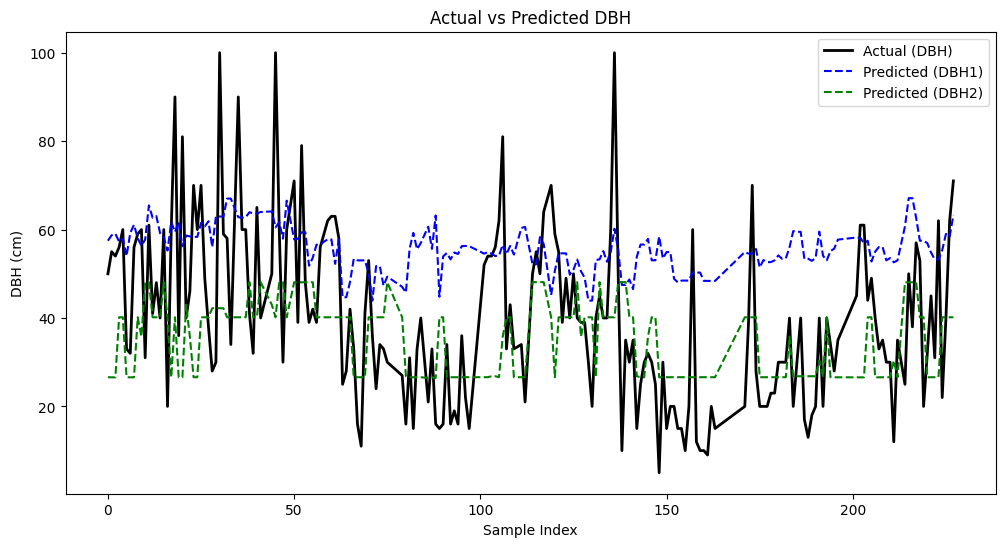

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['DBH'], label='Actual (DBH)', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['DBH1'], label='Predicted (DBH1)', color='blue', linestyle='--')
plt.plot(gdf_gcps.index, gdf_gcps['DBH2'], label='Predicted (DBH2)', color='green', linestyle='--')

plt.xlabel('Sample Index')
plt.ylabel('DBH (cm)')
plt.title('Actual vs Predicted DBH')
plt.legend()
plt.show()

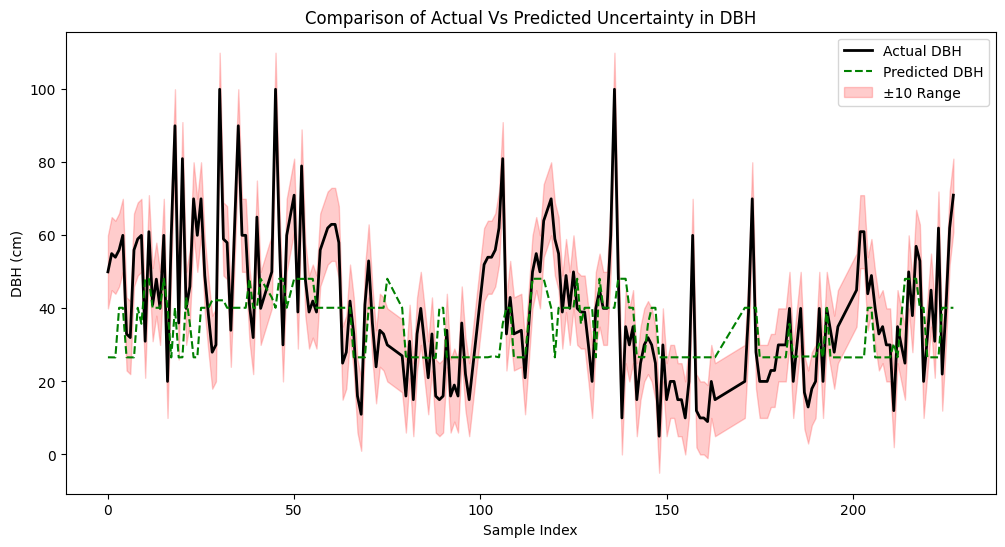

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['DBH'], label='Actual DBH', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['DBH2'], label='Predicted DBH', color='green', linestyle='--')

# Add shaded region for ±10 around actual DBH
plt.fill_between(gdf_gcps.index, gdf_gcps['DBH'] - 10, gdf_gcps['DBH'] + 10, color='red', alpha=0.2, label='±10 Range')

plt.xlabel('Sample Index')
plt.ylabel('DBH (cm)')
plt.title('Comparison of Actual Vs Predicted Uncertainty in DBH')
plt.legend()
plt.show()

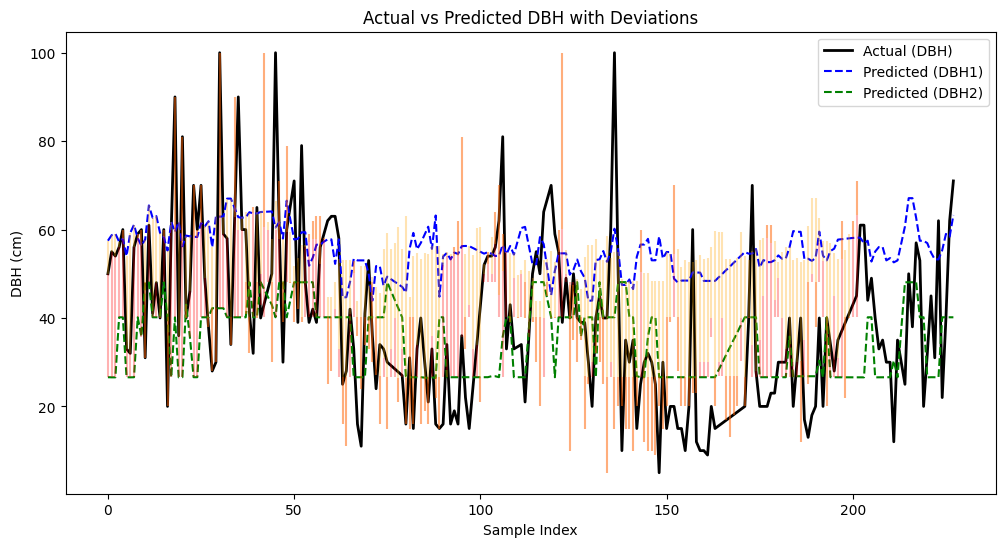

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['DBH'], label='Actual (DBH)', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['DBH1'], label='Predicted (DBH1)', color='blue', linestyle='--')
plt.plot(gdf_gcps.index, gdf_gcps['DBH2'], label='Predicted (DBH2)', color='green', linestyle='--')

# Plot deviations as shaded regions for DBH2 (fitted model)
for i in range(len(gdf_gcps)):
    plt.vlines(x=i, ymin=gdf_gcps['DBH'].iloc[i], ymax=gdf_gcps['DBH2'].iloc[i], color='red', alpha=0.3)
    plt.vlines(x=i, ymin=gdf_gcps['DBH'].iloc[i], ymax=gdf_gcps['DBH1'].iloc[i], color='orange', alpha=0.3)

plt.xlabel('Sample Index')
plt.ylabel('DBH (cm)')
plt.title('Actual vs Predicted DBH with Deviations')
plt.legend()
plt.show()

Sample for H

In [ ]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential values
# gdf["label"] = range(1, len(gdf) + 1)

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)


In [ ]:
gdf_gcps = gdf_gcps.drop(columns=["DBH"])

In [ ]:
gdf_gcps.head()

,H,geometry
0,21.0312,POINT (35.14802 1.26881)
1,21.3360,POINT (35.14828 1.26873)
2,20.7264,POINT (35.14832 1.2687)
3,14.3256,POINT (35.14862 1.26982)
4,21.3360,POINT (35.14867 1.26986)


In [ ]:
import rasterio
from rasterio.sample import sample_gen

# Paths to your raster files
raster_path_1 = "/content/drive/MyDrive/Kamatira Model Data/Tree_Height_2024_Predicted.tif"
raster_path_2 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM/H_Predicted_2024.tif"

# Function to extract raster values at point locations
def extract_raster_values(gdf, raster_path, new_column_name):
    with rasterio.open(raster_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf.geometry]
        values = [val[0] for val in src.sample(coords)]
        gdf[new_column_name] = values
    return gdf

# Make a copy to avoid modifying the original
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_1, 'H2')
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_2, 'H1')

print(gdf_gcps)

           H                  geometry         H2         H1
0    21.0312  POINT (35.14802 1.26881)  21.903711  32.705322
1    21.3360  POINT (35.14828 1.26873)  19.762766  31.575428
2    20.7264   POINT (35.14832 1.2687)  19.732622  31.781422
3    14.3256  POINT (35.14862 1.26982)  19.809267  27.096146
4    21.3360  POINT (35.14867 1.26986)  21.581184  29.289057
..       ...                       ...        ...        ...
223   2.1336  POINT (35.17271 1.26681)   6.150899  26.736458
224  13.7160  POINT (35.18311 1.27027)  22.509432  24.213900
225  17.6784  POINT (35.18322 1.27023)  28.543102  24.119318
226  21.6408  POINT (35.18277 1.27107)  28.635710  28.445826
227  20.7264  POINT (35.18099 1.27238)  34.023243  28.815407

[228 rows x 4 columns]


In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Keep only data within bounds
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

# Remove outliers in each column
gdf_gcps = remove_outliers(gdf_gcps, 'H')
gdf_gcps = remove_outliers(gdf_gcps, 'H1')
gdf_gcps = remove_outliers(gdf_gcps, 'H2')

print("Data after removing outliers:")
print(gdf_gcps)

Data after removing outliers:
           H                  geometry         H2         H1
0    21.0312  POINT (35.14802 1.26881)  21.903711  32.705322
1    21.3360  POINT (35.14828 1.26873)  19.762766  31.575428
2    20.7264   POINT (35.14832 1.2687)  19.732622  31.781422
3    14.3256  POINT (35.14862 1.26982)  19.809267  27.096146
4    21.3360  POINT (35.14867 1.26986)  21.581184  29.289057
..       ...                       ...        ...        ...
223   2.1336  POINT (35.17271 1.26681)   6.150899  26.736458
224  13.7160  POINT (35.18311 1.27027)  22.509432  24.213900
225  17.6784  POINT (35.18322 1.27023)  28.543102  24.119318
226  21.6408  POINT (35.18277 1.27107)  28.635710  28.445826
227  20.7264  POINT (35.18099 1.27238)  34.023243  28.815407

[220 rows x 4 columns]


In [ ]:
gdf_gcps.head(10)

,H,geometry,H2,H1
0,21.0312,POINT (35.14802 1.26881),21.903711,32.705322
1,21.3360,POINT (35.14828 1.26873),19.762766,31.575428
2,20.7264,POINT (35.14832 1.2687),19.732622,31.781422
3,14.3256,POINT (35.14862 1.26982),19.809267,27.096146
4,21.3360,POINT (35.14867 1.26986),21.581184,29.289057
5,7.6200,POINT (35.14961 1.26957),11.074958,23.930174
6,7.9248,POINT (35.14982 1.26977),10.897241,25.033716
7,24.6888,POINT (35.14981 1.26978),10.986849,25.031839
8,23.1648,POINT (35.15046 1.27084),23.566923,29.306213
9,22.5552,POINT (35.15033 1.2711),27.733795,27.066658


In [ ]:
import numpy as np

def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Actual values
actual_values = gdf_gcps['H']

# Predictions
pred1 = gdf_gcps['H1']
pred2 = gdf_gcps['H2']

# Calculate RMSE for each prediction
rmse_pred1 = calculate_rmse(actual_values, pred1)
rmse_pred2 = calculate_rmse(actual_values, pred2)

print(f"RMSE for Prediction 1 (H1): {rmse_pred1}")
print(f"RMSE for Prediction 2 (H2): {rmse_pred2}")

RMSE for Prediction 1 (H1): 15.268282159562274
RMSE for Prediction 2 (H2): 5.926945222037919


In [ ]:
import pandas as pd

df = gdf_gcps
# Calculate the mean height
mean_height = df['H1'].mean()

# RMSE value
rmse = 4.858

# Calculate percentage error
percentage_error = (rmse / mean_height) * 100

print(f"Average Height: {mean_height:.2f} meters")
print(f"Uncertainty as percentage of average height: {percentage_error:.2f}%")

Average Height: 25.97 meters
Uncertainty as percentage of average height: 18.71%


In [ ]:
# Calculate the uncertainty as the standard deviation of the predictions
gdf_gcps['Prediction_Uncertainty'] = gdf_gcps[['H1', 'H2']].std(axis=1)

print("Sample of uncertainty (standard deviation of predictions):")
print(gdf_gcps['Prediction_Uncertainty'].head())

Sample of uncertainty (standard deviation of predictions):
0    7.637893
1    8.352814
2    8.519788
3    5.152601
4    5.450289
Name: Prediction_Uncertainty, dtype: float32


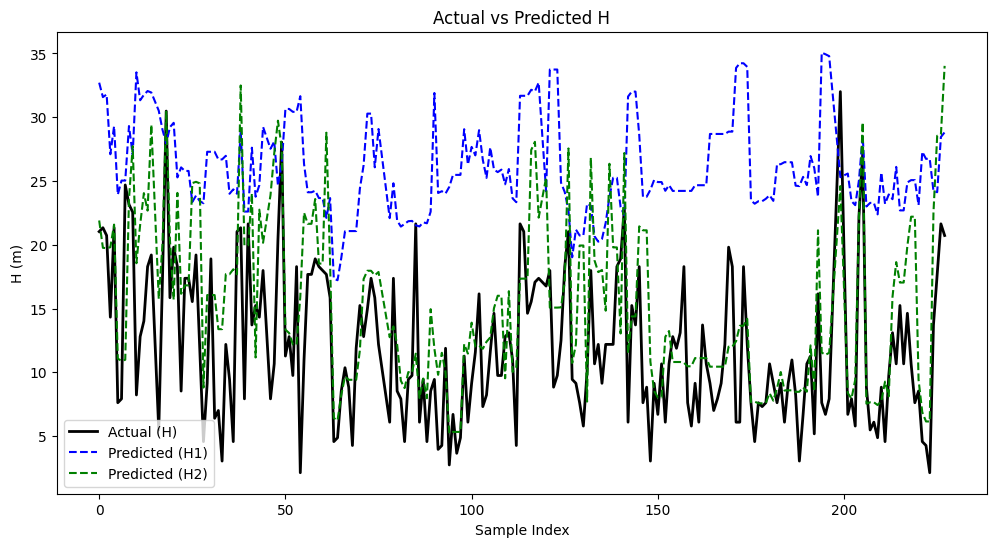

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['H'], label='Actual (H)', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['H1'], label='Predicted (H1)', color='blue', linestyle='--')
plt.plot(gdf_gcps.index, gdf_gcps['H2'], label='Predicted (H2)', color='green', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('H (m)')
plt.title('Actual vs Predicted H')
plt.legend()
plt.show()

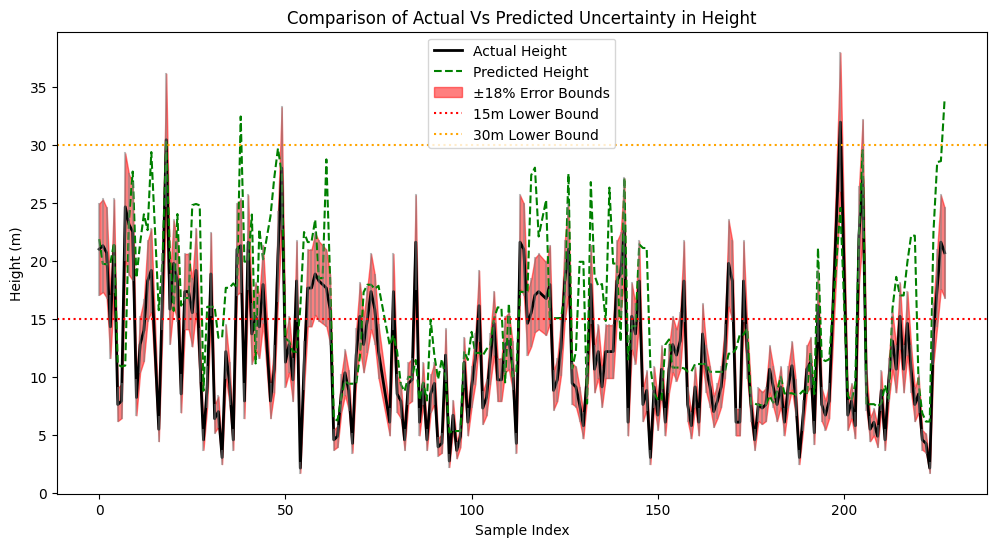

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Plot actual heights
plt.plot(gdf_gcps.index, gdf_gcps['H'], label='Actual Height', color='black', linewidth=2)
# Plot predicted heights (H2)
plt.plot(gdf_gcps.index, gdf_gcps['H2'], label='Predicted Height', color='green', linestyle='--')

# Add horizontal bounds for the ±18% uncertainty around actual height
# Calculate bounds
lower_bound = gdf_gcps['H'] * (1 - 0.1871)
upper_bound = gdf_gcps['H'] * (1 + 0.1871)

# Plot bounds as lines
for idx in gdf_gcps.index:
    plt.plot([idx, idx], [lower_bound[idx], upper_bound[idx]], color='gray', alpha=0.5)

# Alternatively, add shaded area to represent uncertainty bounds
plt.fill_between(gdf_gcps.index, lower_bound, upper_bound, color='red', alpha=0.5, label='±18% Error Bounds')

# Add horizontal lines for fixed bounds (if needed)
plt.axhline(y=15, color='red', linestyle=':', label='15m Lower Bound')
plt.axhline(y=30, color='orange', linestyle=':', label='30m Lower Bound')

plt.xlabel('Sample Index')
plt.ylabel('Height (m)')
plt.title('Comparison of Actual Vs Predicted Uncertainty in Height')
plt.legend()
plt.show()

In [ ]:
# Calculate ranges for H1 and H2
range_H1 = (gdf_gcps['H1'].min(), gdf_gcps['H1'].max())
range_H2 = (gdf_gcps['H2'].min(), gdf_gcps['H2'])

print(f"Range of H1: {range_H1[0]} to {range_H1[1]}")
print(f"Range of H2: {range_H2[0]} to {range_H2[1]}")

Range of H1: 17.22139549255371 to 35.053314208984375
Range of H2: 5.219701766967773 to 0      21.903711
1      19.762766
2      19.732622
3      19.809267
4      21.581184
         ...    
223     6.150899
224    22.509432
225    28.543102
226    28.635710
227    34.023243
Name: H2, Length: 220, dtype: float32


In [ ]:
range_H2

(5.219701766967773,
 0      21.903711
 1      19.762766
 2      19.732622
 3      19.809267
 4      21.581184
          ...    
 223     6.150899
 224    22.509432
 225    28.543102
 226    28.635710
 227    34.023243
 Name: H2, Length: 220, dtype: float32)

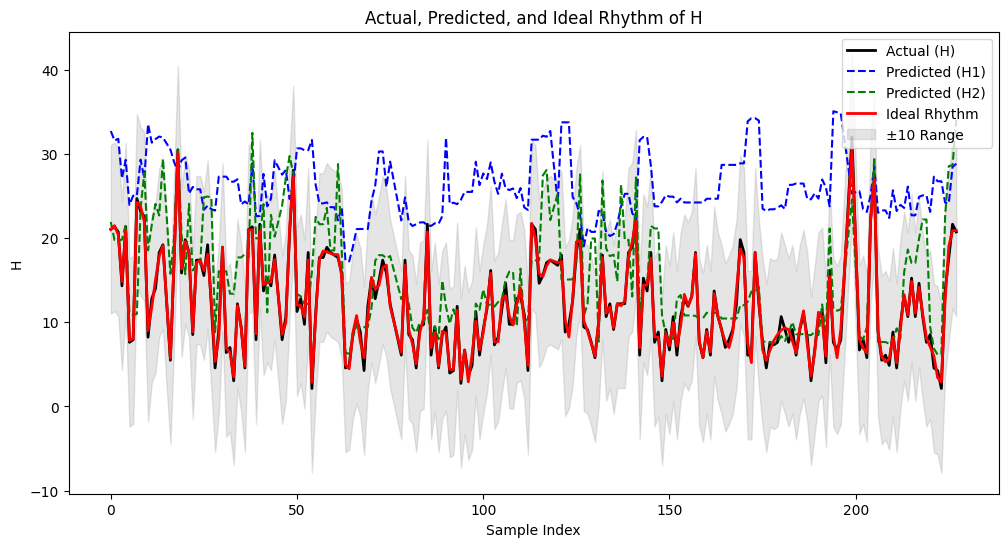

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

# Assuming gdf_gcps is your DataFrame
x = np.arange(len(gdf_gcps))
y = gdf_gcps['H']

# Fit a smooth spline to the actual H data
spline = UnivariateSpline(x, y, s=0.5 * len(gdf_gcps))  # Adjust s for smoothness
y_smooth = spline(x)

plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['H'], label='Actual (H)', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['H1'], label='Predicted (H1)', color='blue', linestyle='--')
plt.plot(gdf_gcps.index, gdf_gcps['H2'], label='Predicted (H2)', color='green', linestyle='--')

# Plot the smooth "perfect" rhythm curve
plt.plot(gdf_gcps.index, y_smooth, color='red', linewidth=2, label='Ideal Rhythm')

# Optional: Add ±10 range
plt.fill_between(gdf_gcps.index, gdf_gcps['H'] - 10, gdf_gcps['H'] + 10, color='gray', alpha=0.2, label='±10 Range')

plt.xlabel('Sample Index')
plt.ylabel('H')
plt.title('Actual, Predicted, and Ideal Rhythm of H')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Replace these with your actual measured heights
H1 = 20  # example value for H1
H2 = 22  # example value for H2

# Confidence interval offsets
rmse = 5.9
interval_68 = rmse
interval_95 = 2 * rmse

# Create data for H1
data = {
    'Measurement': ['H1', 'H2'],
    'Measured Height': [H1, H2],
    '68% Confidence Interval Lower': [H1 - interval_68, H2 - interval_68],
    '68% Confidence Interval Upper': [H1 + interval_68, H2 + interval_68],
    '95% Confidence Interval Lower': [H1 - interval_95, H2 - interval_95],
    '95% Confidence Interval Upper': [H1 + interval_95, H2 + interval_95],
    'Ideal Height Range': ['15-30 meters', '15-30 meters']
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

  Measurement  Measured Height  68% Confidence Interval Lower  \
0          H1               20                           14.1   
1          H2               22                           16.1   

   68% Confidence Interval Upper  95% Confidence Interval Lower  \
0                           25.9                            8.2   
1                           27.9                           10.2   

   95% Confidence Interval Upper Ideal Height Range  
0                           31.8       15-30 meters  
1                           33.8       15-30 meters  


In [ ]:
df.head()

,Measurement,Measured Height,68% Confidence Interval Lower,68% Confidence Interval Upper,95% Confidence Interval Lower,95% Confidence Interval Upper,Ideal Height Range
0,H1,20,14.1,25.9,8.2,31.8,15-30 meters
1,H2,22,16.1,27.9,10.2,33.8,15-30 meters


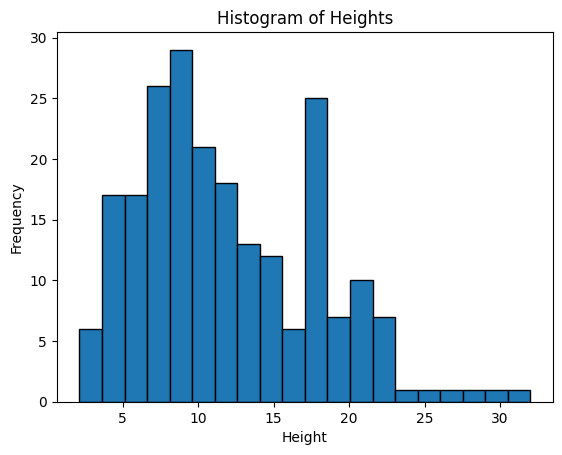

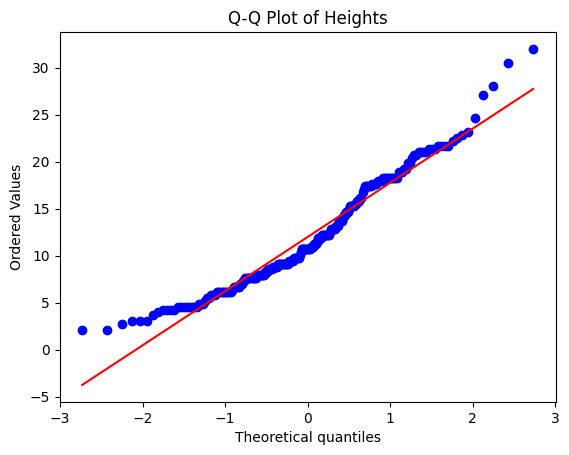

Shapiro-Wilk Test statistic: 0.9548029495821544, p-value: 2.0675310399637394e-06
Data does not appear to be normally distributed.


In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Sample data: heights
heights = gdf_gcps['H']

# 1. Histogram
plt.hist(heights, bins=20, edgecolor='k')
plt.title('Histogram of Heights')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

# 2. Q-Q Plot
stats.probplot(heights, dist="norm", plot=plt)
plt.title('Q-Q Plot of Heights')
plt.show()

# 3. Shapiro-Wilk Test
stat, p_value = stats.shapiro(heights)
print(f'Shapiro-Wilk Test statistic: {stat}, p-value: {p_value}')

if p_value > 0.05:
    print("Data appears to be normally distributed.")
else:
    print("Data does not appear to be normally distributed.")

In [ ]:
import pandas as pd

# Assuming gdf_gcps has a column 'H' with the measured heights
heights = gdf_gcps['H']

# Confidence interval offsets
rmse = 5.9
interval_68 = rmse
interval_95 = 2 * rmse

# Create a DataFrame with results for each location
results_df = pd.DataFrame({
    'Location_ID': gdf_gcps.index,  # or use a specific identifier column if available
    'Measured Height': heights,
    '68% CI Lower': heights - interval_68,
    '68% CI Upper': heights + interval_68,
    '95% CI Lower': heights - interval_95,
    '95% CI Upper': heights + interval_95,
    'Ideal Height Range': ['15-30 meters'] * len(gdf_gcps)
})

# Display the results
print(results_df)

     Location_ID  Measured Height  68% CI Lower  68% CI Upper  95% CI Lower  \
0              0          21.0312       15.1312       26.9312        9.2312   
1              1          21.3360       15.4360       27.2360        9.5360   
2              2          20.7264       14.8264       26.6264        8.9264   
3              3          14.3256        8.4256       20.2256        2.5256   
4              4          21.3360       15.4360       27.2360        9.5360   
..           ...              ...           ...           ...           ...   
223          223           2.1336       -3.7664        8.0336       -9.6664   
224          224          13.7160        7.8160       19.6160        1.9160   
225          225          17.6784       11.7784       23.5784        5.8784   
226          226          21.6408       15.7408       27.5408        9.8408   
227          227          20.7264       14.8264       26.6264        8.9264   

     95% CI Upper Ideal Height Range  
0         32

In [ ]:
gdf_gcps.head()

,H,geometry,H2,H1,Prediction_Uncertainty
0,21.0312,POINT (35.14802 1.26881),21.903711,32.705322,7.637893
1,21.3360,POINT (35.14828 1.26873),19.762766,31.575428,8.352814
2,20.7264,POINT (35.14832 1.2687),19.732622,31.781422,8.519788
3,14.3256,POINT (35.14862 1.26982),19.809267,27.096146,5.152601
4,21.3360,POINT (35.14867 1.26986),21.581184,29.289057,5.450289


In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

# Assuming gdf_gcps is your DataFrame
# Extract the relevant columns
actual_heights = gdf_gcps['H']
predicted_H1 = gdf_gcps['H1']
predicted_H2 = gdf_gcps['H2']

# Wilcoxon test comparing actual height with predicted sample 1
stat_H_vs_H1, p_value_H_vs_H1 = wilcoxon(actual_heights, predicted_H1)

# Wilcoxon test comparing actual height with predicted sample 2
stat_H_vs_H2, p_value_H_vs_H2 = wilcoxon(actual_heights, predicted_H2)

# Print the results
print(f"Comparison between actual height and predicted H1: statistic={stat_H_vs_H1}, p-value={p_value_H_vs_H1}")
print(f"Comparison between actual height and predicted H2: statistic={stat_H_vs_H2}, p-value={p_value_H_vs_H2}")

Comparison between actual height and predicted H1: statistic=45.0, p-value=1.401385198423796e-37
Comparison between actual height and predicted H2: statistic=4352.0, p-value=1.5133589433159163e-16


In [ ]:
import numpy as np
import scipy.stats as stats

# Differences
diff_H1 = gdf_gcps['H'] - gdf_gcps['H1']
diff_H2 = gdf_gcps['H'] - gdf_gcps['H2']

# Function to compute bootstrap confidence interval for median
def bootstrap_ci(data, num_bootstrap=1000, confidence=0.95):
    medians = []
    n = len(data)
    for _ in range(num_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        medians.append(np.median(sample))
    lower = np.percentile(medians, (1 - confidence) / 2 * 100)
    upper = np.percentile(medians, (1 + confidence) / 2 * 100)
    return lower, upper

# Compute bootstrap CIs
ci_H1 = bootstrap_ci(diff_H1)
ci_H2 = bootstrap_ci(diff_H2)

print(f"95% CI for median difference (H - H1): {ci_H1}")
print(f"95% CI for median difference (H - H2): {ci_H2}")

95% CI for median difference (H - H1): (np.float64(-15.436839302787781), np.float64(-13.290567964057924))
95% CI for median difference (H - H2): (np.float64(-3.4023175506591796), np.float64(-1.9020726242065429))


Etals's EQN Test

In [ ]:
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
import pandas as pd
import geopandas as gpd
# Load the GeoJSON file
gdf_gcps = gpd.read_file(path2)
gdf_gcps.head(2)
# # Add 'label' column with sequential values
# gdf["label"] = range(1, len(gdf) + 1)

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)


In [ ]:
gdf_gcps.head()

,DBH,H,geometry
0,0.50,21.0312,POINT (35.14802 1.26881)
1,0.55,21.3360,POINT (35.14828 1.26873)
2,0.54,20.7264,POINT (35.14832 1.2687)
3,0.56,14.3256,POINT (35.14862 1.26982)
4,0.60,21.3360,POINT (35.14867 1.26986)


In [ ]:
gdf_gcps['DBH'] = gdf_gcps['DBH'] * 100

In [ ]:
gdf_gcps.head()

,DBH,H,geometry
0,50.0,21.0312,POINT (35.14802 1.26881)
1,55.0,21.3360,POINT (35.14828 1.26873)
2,54.0,20.7264,POINT (35.14832 1.2687)
3,56.0,14.3256,POINT (35.14862 1.26982)
4,60.0,21.3360,POINT (35.14867 1.26986)


In [ ]:
wood_density = 0.598  # g/cm³, adjust as necessary

gdf_gcps['Biomass_kg'] = 0.0673 * ((wood_density * gdf_gcps['DBH']**2 * gdf_gcps['H']) ** 0.976)
gdf_gcps.head()

,DBH,H,geometry,Biomass_kg
0,50.0,21.0312,POINT (35.14802 1.26881),1650.365682
1,55.0,21.3360,POINT (35.14828 1.26873),2015.940363
2,54.0,20.7264,POINT (35.14832 1.2687),1890.755365
3,56.0,14.3256,POINT (35.14862 1.26982),1415.482686
4,60.0,21.3360,POINT (35.14867 1.26986),2389.136433


In [ ]:
# Check CRS of the GeoDataFrame
print("gdf_gcps CRS:", gdf_gcps.crs)

# Check CRS of the raster files
import rasterio

with rasterio.open(raster_path_1) as src:
    raster_crs_1 = src.crs
print("Raster 1 CRS:", raster_crs_1)

with rasterio.open(raster_path_2) as src:
    raster_crs_2 = src.crs
print("Raster 2 CRS:", raster_crs_2)

gdf_gcps CRS: EPSG:4326
Raster 1 CRS: EPSG:4326
Raster 2 CRS: EPSG:4326


In [ ]:
import rasterio
from rasterio.sample import sample_gen

# Paths to your raster files
raster_path_1 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled_Allometric_Biomass/AGB_individual_2024_2025_reprojected.tif"
raster_path_2 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/AGB/WGS/AGB_Predicted_2024.tif"

# Function to extract raster values at point locations
def extract_raster_values(gdf, raster_path, new_column_name):
    with rasterio.open(raster_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf.geometry]
        values = [val[0] for val in src.sample(coords)]
        gdf[new_column_name] = values
    return gdf

# Make a copy to avoid modifying the original
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_1, 'AGB2')
gdf_gcps = extract_raster_values(gdf_gcps, raster_path_2, 'AGB1')
print(gdf_gcps)

      DBH        H                  geometry   Biomass_kg         AGB2  \
0    50.0  21.0312  POINT (35.14802 1.26881)  1650.365682   499.659668   
1    55.0  21.3360  POINT (35.14828 1.26873)  2015.940363   439.491577   
2    54.0  20.7264   POINT (35.14832 1.2687)  1890.755365   439.491577   
3    56.0  14.3256  POINT (35.14862 1.26982)  1415.482686   945.071167   
4    60.0  21.3360  POINT (35.14867 1.26986)  2389.136433  1100.228638   
..    ...      ...                       ...          ...          ...   
223  62.0   2.1336  POINT (35.17271 1.26681)   269.177211   148.484406   
224  22.0  13.7160  POINT (35.18311 1.27027)   218.987089  1215.445557   
225  40.0  17.6784  POINT (35.18322 1.27023)   901.157804  1373.929688   
226  62.0  21.6408  POINT (35.18277 1.27107)  2582.561959  1584.778076   
227  71.0  20.7264  POINT (35.18099 1.27238)  3225.960303  1611.746948   

            AGB1  
0    1309.899658  
1    1340.350464  
2    1280.317139  
3     937.398926  
4    1190.641846

In [ ]:
import numpy as np

# Example data
wood_density = 0.598  # g/cm³

# Original biomass
gdf_gcps['Biomass_kg'] = 0.0673 * ((wood_density * gdf_gcps['DBH']**2 * gdf_gcps['H']) ** 0.976)

# Apply uncertainties
DBH_error = 0.1074  # ±10.74%
H_error = 0.18      # ±18%

# Upper and lower bounds
DBH_upper = gdf_gcps['DBH'] * (1 + DBH_error)
DBH_lower = gdf_gcps['DBH'] * (1 - DBH_error)

H_upper = gdf_gcps['H'] * (1 + H_error)
H_lower = gdf_gcps['H'] * (1 - H_error)

# Compute biomass bounds using Chave et al. equation
gdf_gcps['Biomass_kg_upper'] = 0.0673 * ((wood_density * DBH_upper**2 * H_upper) ** 0.976)
gdf_gcps['Biomass_kg_lower'] = 0.0673 * ((wood_density * DBH_lower**2 * H_lower) ** 0.976)

# Check resulting dataframe
gdf_gcps[['DBH','H','Biomass_kg','Biomass_kg_lower','Biomass_kg_upper']].head()


,DBH,H,Biomass_kg,Biomass_kg_lower,Biomass_kg_upper
0,50.0,21.0312,1650.365682,1089.293066,2367.115477
1,55.0,21.3360,2015.940363,1330.583810,2891.458350
2,54.0,20.7264,1890.755365,1247.957789,2711.905812
3,56.0,14.3256,1415.482686,934.262928,2030.223367
4,60.0,21.3360,2389.136433,1576.904911,3426.732564


In [ ]:
wood_density = 0.598  # g/cm³

gdf_gcps['Biomass_kg'] = 0.0673 * (
    (wood_density * gdf_gcps['DBH']**2 * gdf_gcps['H']) ** 0.976
)


In [ ]:
# Elasticities from Chave et al.
E_DBH = 1.952
E_H = 0.976

# Measurement uncertainties (%)
err_DBH = 10.74
err_H = 18.0

# Biomass uncertainty contributions (%)
gdf_gcps['AGB_unc_DBH_pct'] = E_DBH * err_DBH
gdf_gcps['AGB_unc_H_pct'] = E_H * err_H


In [ ]:
gdf_gcps['AGB_unc_total_pct'] = np.sqrt(
    gdf_gcps['AGB_unc_DBH_pct']**2 +
    gdf_gcps['AGB_unc_H_pct']**2
)


In [ ]:
gdf_gcps['Biomass_kg_lower'] = gdf_gcps['Biomass_kg'] * (
    1 - gdf_gcps['AGB_unc_total_pct'] / 100
)

gdf_gcps['Biomass_kg_upper'] = gdf_gcps['Biomass_kg'] * (
    1 + gdf_gcps['AGB_unc_total_pct'] / 100
)


In [ ]:
gdf_gcps['DBH_share'] = (
    gdf_gcps['AGB_unc_DBH_pct']**2 /
    gdf_gcps['AGB_unc_total_pct']**2
) * 100

gdf_gcps['H_share'] = (
    gdf_gcps['AGB_unc_H_pct']**2 /
    gdf_gcps['AGB_unc_total_pct']**2
) * 100


In [ ]:
import numpy as np

# Constants
wood_density = 0.598   # g/cm³
DBH_dev = 0.1074       # ±10.74%
H_dev = 0.18           # ±18%

# Baseline biomass (Chave et al.)
AGB_base = 0.0673 * (
    (wood_density * gdf_gcps['DBH']**2 * gdf_gcps['H']) ** 0.976
)

# DBH deviation impact
AGB_DBH_plus = 0.0673 * (
    (wood_density * (gdf_gcps['DBH'] * (1 + DBH_dev))**2 * gdf_gcps['H']) ** 0.976
)
AGB_DBH_minus = 0.0673 * (
    (wood_density * (gdf_gcps['DBH'] * (1 - DBH_dev))**2 * gdf_gcps['H']) ** 0.976
)

DBH_effect_pct = ((AGB_DBH_plus - AGB_DBH_minus) / (2 * AGB_base)) * 100

# Height deviation impact
AGB_H_plus = 0.0673 * (
    (wood_density * gdf_gcps['DBH']**2 * (gdf_gcps['H'] * (1 + H_dev))) ** 0.976
)
AGB_H_minus = 0.0673 * (
    (wood_density * gdf_gcps['DBH']**2 * (gdf_gcps['H'] * (1 - H_dev))) ** 0.976
)

H_effect_pct = ((AGB_H_plus - AGB_H_minus) / (2 * AGB_base)) * 100

# Final single empirical result
print(
    f"Mean biomass deviation due to DBH (±10.74%): {DBH_effect_pct.mean():.2f}%\n"
    f"Mean biomass deviation due to Height (±18%): {H_effect_pct.mean():.2f}%"
)


Mean biomass deviation due to DBH (±10.74%): 20.96%
Mean biomass deviation due to Height (±18%): 17.57%


In [ ]:
import pandas as pd

# Define a function to remove outliers based on IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter the DataFrame to keep only non-outliers
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

# Apply outlier removal for each relevant column
columns_to_check = ['Biomass_kg', 'AGB2', 'AGB1']

for col in columns_to_check:
    gdf_gcps = remove_outliers(gdf_gcps, col)

print("Outliers removed. Remaining data:")
print(gdf_gcps)

Outliers removed. Remaining data:
      DBH        H                  geometry   Biomass_kg         AGB2  \
0    50.0  21.0312  POINT (35.14802 1.26881)  1650.365682   499.659668   
1    55.0  21.3360  POINT (35.14828 1.26873)  2015.940363   439.491577   
2    54.0  20.7264   POINT (35.14832 1.2687)  1890.755365   439.491577   
3    56.0  14.3256  POINT (35.14862 1.26982)  1415.482686   945.071167   
4    60.0  21.3360  POINT (35.14867 1.26986)  2389.136433  1100.228638   
..    ...      ...                       ...          ...          ...   
223  62.0   2.1336  POINT (35.17271 1.26681)   269.177211   148.484406   
224  22.0  13.7160  POINT (35.18311 1.27027)   218.987089  1215.445557   
225  40.0  17.6784  POINT (35.18322 1.27023)   901.157804  1373.929688   
226  62.0  21.6408  POINT (35.18277 1.27107)  2582.561959  1584.778076   
227  71.0  20.7264  POINT (35.18099 1.27238)  3225.960303  1611.746948   

            AGB1  
0    1309.899658  
1    1340.350464  
2    1280.317139  
3

In [ ]:
gdf_gcps.head()

,DBH,H,geometry,Biomass_kg,AGB2,AGB1
0,50.0,21.0312,POINT (35.14802 1.26881),1650.365682,499.659668,1309.899658
1,55.0,21.3360,POINT (35.14828 1.26873),2015.940363,439.491577,1340.350464
2,54.0,20.7264,POINT (35.14832 1.2687),1890.755365,439.491577,1280.317139
3,56.0,14.3256,POINT (35.14862 1.26982),1415.482686,945.071167,937.398926
4,60.0,21.3360,POINT (35.14867 1.26986),2389.136433,1100.228638,1190.641846


In [ ]:
print("Biomass_kg stats:")
print(gdf_gcps['Biomass_kg'].describe())

Q1_biomass = gdf_gcps['Biomass_kg'].quantile(0.25)
Q3_biomass = gdf_gcps['Biomass_kg'].quantile(0.75)
IQR_biomass = Q3_biomass - Q1_biomass
print(f"Q1: {Q1_biomass}, Q3: {Q3_biomass}, IQR: {IQR_biomass}")

# Similarly for AGB1
print("AGB1 stats:")
Q1_agb1 = gdf_gcps['AGB1'].quantile(0.25)
Q3_agb1 = gdf_gcps['AGB1'].quantile(0.75)
IQR_agb1 = Q3_agb1 - Q1_agb1
print(f"Q1: {Q1_agb1}, Q3: {Q3_agb1}, IQR: {IQR_agb1}")

Biomass_kg stats:
count     210.000000
mean      764.329071
std       800.019074
min         2.798102
25%       130.630266
50%       449.245185
75%      1227.447438
max      3225.960303
Name: Biomass_kg, dtype: float64
Q1: 130.63026557885664, Q3: 1227.4474379836822, IQR: 1096.8171724048257
AGB1 stats:
Q1: 775.1647186279297, Q3: 1144.8553161621094, IQR: 369.6905975341797


In [ ]:
df=gdf_gcps
df.head()

,DBH,H,geometry,Biomass_kg,AGB2,AGB1
0,50.0,21.0312,POINT (35.14802 1.26881),1650.365682,499.659668,1309.899658
1,55.0,21.3360,POINT (35.14828 1.26873),2015.940363,439.491577,1340.350464
2,54.0,20.7264,POINT (35.14832 1.2687),1890.755365,439.491577,1280.317139
3,56.0,14.3256,POINT (35.14862 1.26982),1415.482686,945.071167,937.398926
4,60.0,21.3360,POINT (35.14867 1.26986),2389.136433,1100.228638,1190.641846


In [ ]:
import pandas as pd
import numpy as np

def detect_z_score_outliers(df, column, threshold=3):
    mean = df[column].mean()
    std = df[column].std()
    # Calculate Z-scores
    df['z_score'] = (df[column] - mean) / std
    # Filter out outliers
    filtered_df = df[np.abs(df['z_score']) <= threshold]
    return filtered_df

# Example usage:
gdf_no_outliers = detect_z_score_outliers(gdf_gcps, 'Biomass_kg', threshold=3)

In [ ]:
gdf_no_outliers.head()

,DBH,H,geometry,Biomass_kg,AGB2,AGB1,z_score
0,50.0,21.0312,POINT (35.14802 1.26881),1650.365682,499.659668,1309.899658,1.107519
1,55.0,21.3360,POINT (35.14828 1.26873),2015.940363,439.491577,1340.350464,1.564477
2,54.0,20.7264,POINT (35.14832 1.2687),1890.755365,439.491577,1280.317139,1.407999
3,56.0,14.3256,POINT (35.14862 1.26982),1415.482686,945.071167,937.398926,0.813923
4,60.0,21.3360,POINT (35.14867 1.26986),2389.136433,1100.228638,1190.641846,2.030961


In [ ]:
import pandas as pd
import numpy as np

# Example: compute absolute error
gdf_gcps['abs_error'] = gdf_gcps['AGB1'] - gdf_gcps['Biomass_kg']

# Check how many predictions are within ±10.74 kg
within_abs = ((gdf_gcps['abs_error'] >= -10.74) & (gdf_gcps['abs_error'] <= 10.74))
print(f"Number of predictions within ±10.74 kg: {within_abs.sum()} / {len(gdf_gcps)}")


Number of predictions within ±10.74 kg: 2 / 210


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Assuming gdf_gcps is your DataFrame

# Step 1: Calculate deviation percentage for each record
gdf_gcps['deviation_pct'] = ((gdf_gcps['Biomass_kg'] - gdf_gcps['AGB2']) / gdf_gcps['Biomass_kg']) * 100

# Step 2: Calculate average deviation
average_deviation = gdf_gcps['deviation_pct'].mean()

# Step 3: Calculate standard deviation (uncertainty) of deviations
deviation_std = gdf_gcps['deviation_pct'].std()

# Step 4: Calculate 95% confidence interval for the mean deviation
n = len(gdf_gcps['deviation_pct'])
se = deviation_std / np.sqrt(n)
confidence = 0.95
h = se * stats.t.ppf((1 + confidence) / 2., n-1)
ci_lower = average_deviation - h
ci_upper = average_deviation + h

# Output the results
print(f"Average deviation from actual biomass: {average_deviation:.2f}%")
print(f"Uncertainty (standard deviation): {deviation_std:.2f}%")
print(f"95% Confidence interval for mean deviation: ({ci_lower:.2f}%, {ci_upper:.2f}%)")

Average deviation from actual biomass: -348.42%
Uncertainty (standard deviation): 1732.09%
95% Confidence interval for mean deviation: (-584.05%, -112.79%)


In [ ]:
import pandas as pd

# Assuming your DataFrame is named gdf_gcps
# Calculate deviation percentage
gdf_gcps['deviation_pct'] = ((gdf_gcps['Biomass_kg'] - gdf_gcps['AGB2']) / gdf_gcps['Biomass_kg']) * 100

# Calculate average deviation
average_deviation = gdf_gcps['deviation_pct'].mean()

print(f"Average deviation from actual biomass: {average_deviation:.2f}%")

Average deviation from actual biomass: -348.42%


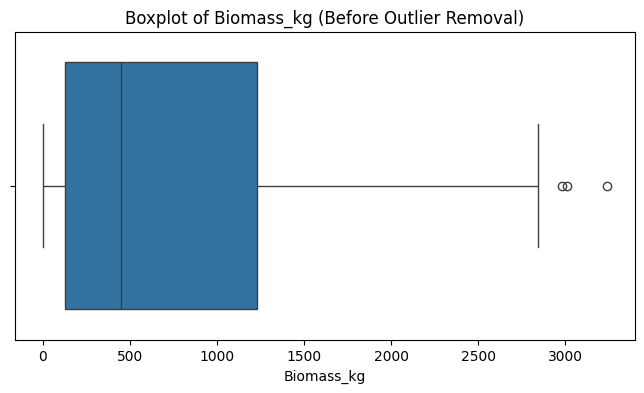

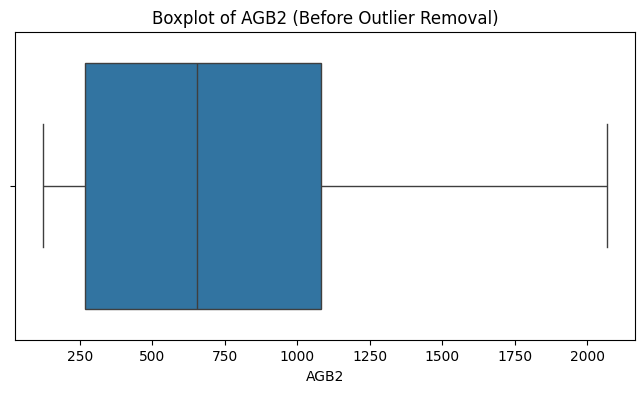

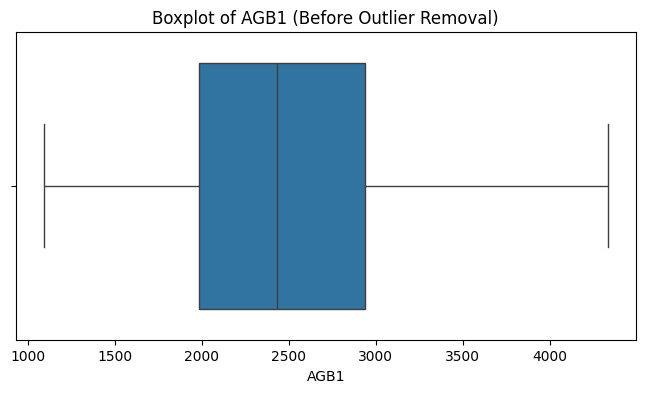

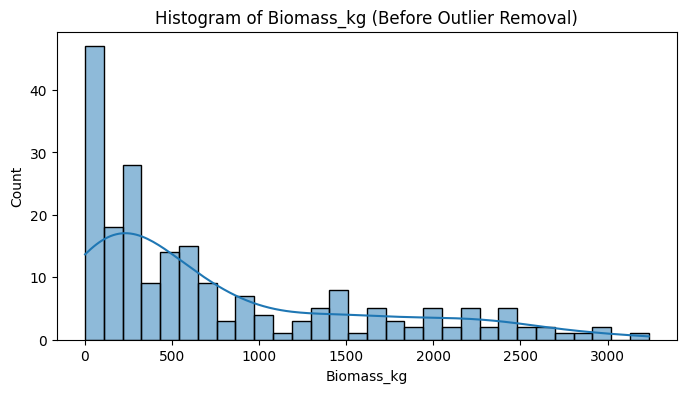

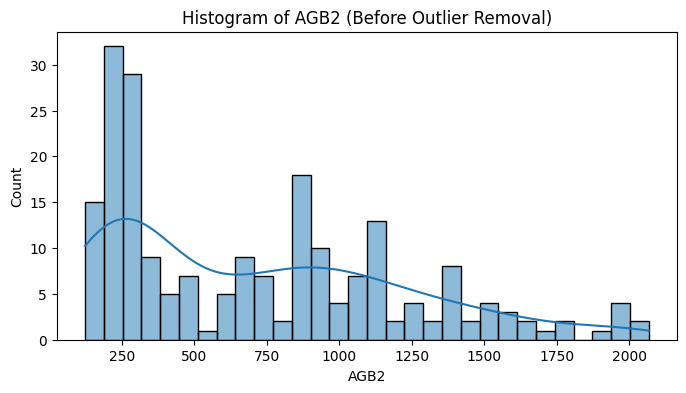

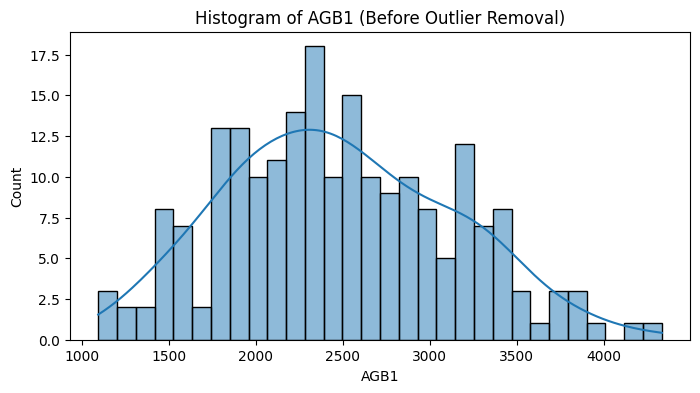

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for each column
for col in columns_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=gdf_gcps[col])
    plt.title(f'Boxplot of {col} (Before Outlier Removal)')
    plt.show()

# Plot histograms for each column
for col in columns_to_check:
    plt.figure(figsize=(8, 4))
    sns.histplot(gdf_gcps[col], bins=30, kde=True)
    plt.title(f'Histogram of {col} (Before Outlier Removal)')
    plt.show()

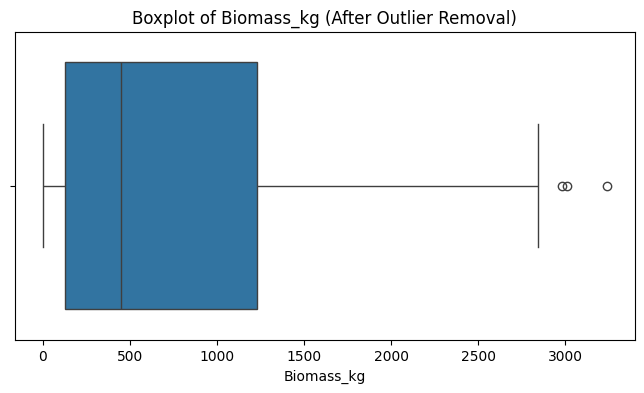

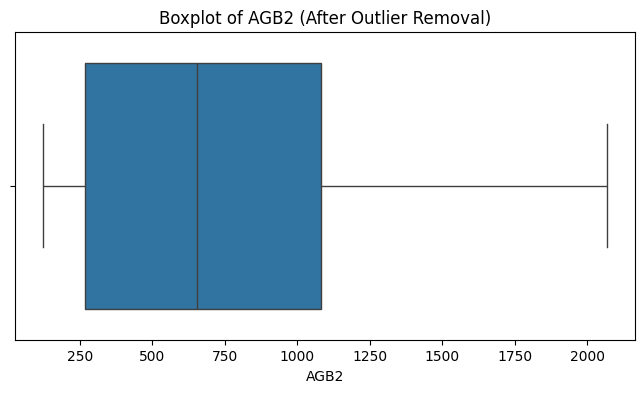

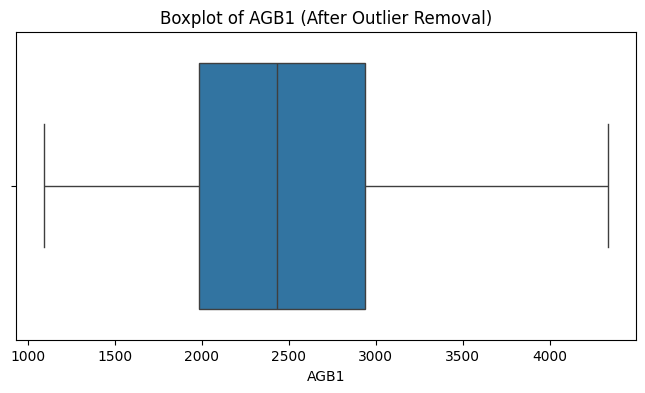

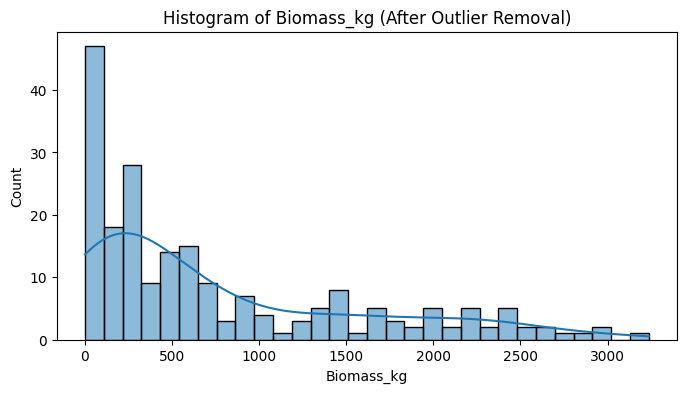

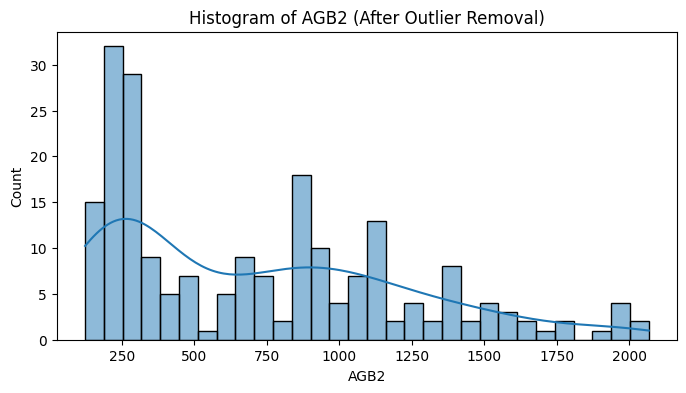

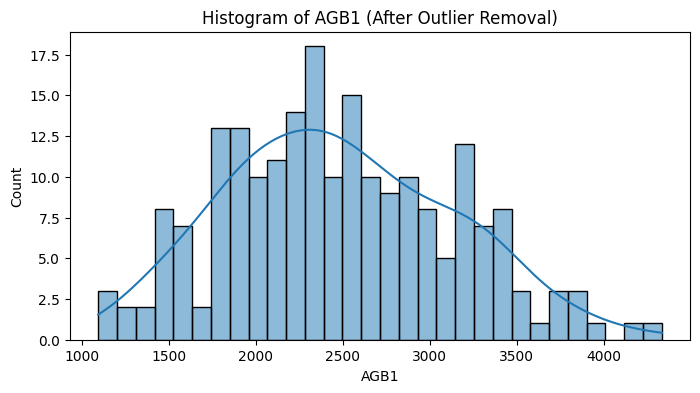

In [ ]:
# Assuming you've already removed outliers and stored in a new DataFrame
# For example, 'gdf_gcps_clean'

# Plot boxplots for each column after removal
for col in columns_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=gdf_gcps[col])
    plt.title(f'Boxplot of {col} (After Outlier Removal)')
    plt.show()

# Plot histograms for each column after removal
for col in columns_to_check:
    plt.figure(figsize=(8, 4))
    sns.histplot(gdf_gcps[col], bins=30, kde=True)
    plt.title(f'Histogram of {col} (After Outlier Removal)')
    plt.show()

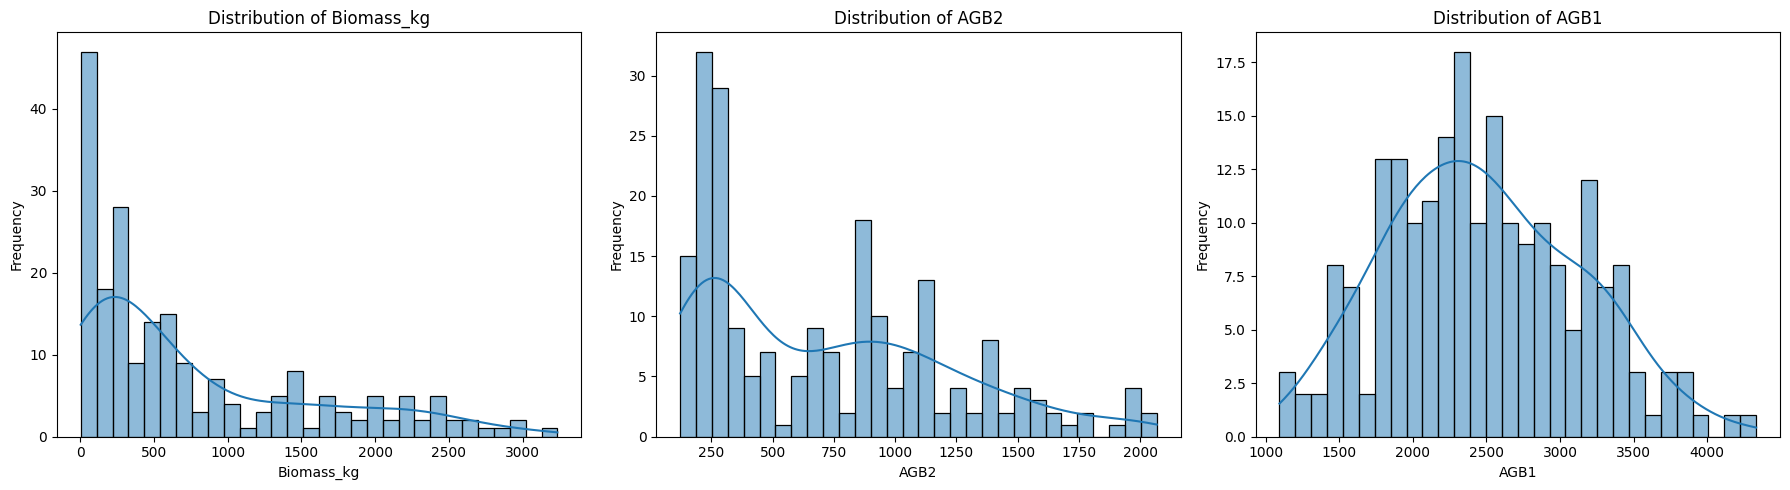

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns = ['Biomass_kg', 'AGB2', 'AGB1']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(columns):
    sns.histplot(gdf_gcps[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

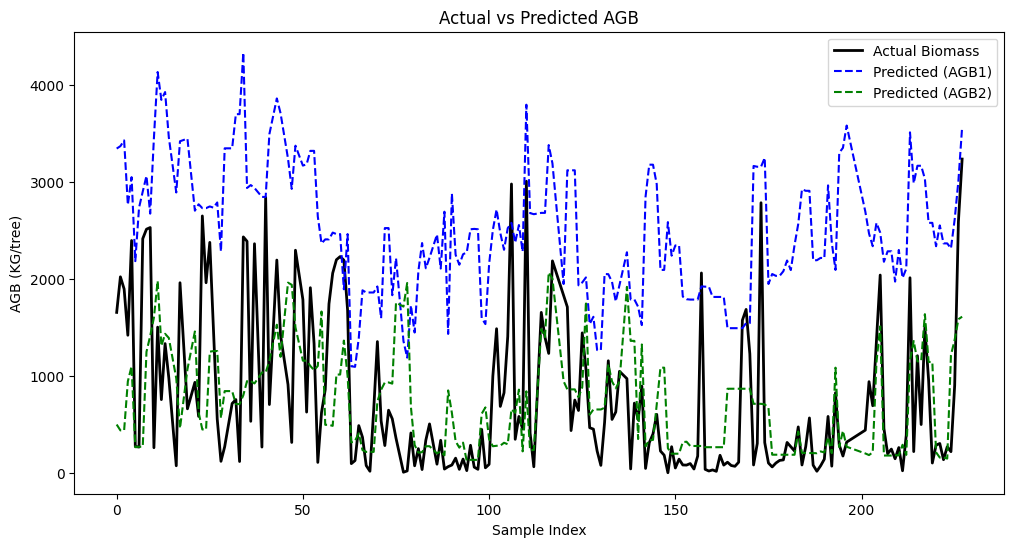

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(gdf_gcps.index, gdf_gcps['Biomass_kg'], label='Actual Biomass', color='black', linewidth=2)
plt.plot(gdf_gcps.index, gdf_gcps['AGB1'], label='Predicted (AGB1)', color='blue', linestyle='--')
plt.plot(gdf_gcps.index, gdf_gcps['AGB2'], label='Predicted (AGB2)', color='green', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('AGB (KG/tree)')
plt.title('Actual vs Predicted AGB')
plt.legend()
plt.show()